# Dataset Exploration

In [35]:
# common imports
import matplotlib.pyplot as plt
from matplotlib import ticker
import polars as pl

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2
plt.rcParams["axes.axisbelow"] = True


## Dataset loading

In [36]:
DATA_DIR = "../../data/v3"
dlf = pl.scan_parquet(f'{DATA_DIR}/pqt/NF-CICIDS2018-v3.parquet')
flf = pl.scan_csv(f'{DATA_DIR}/NetFlow_v3_Features.csv')

display(dlf.head(10).collect(engine="streaming"))
display(flf.head(10).collect(engine="streaming"))

FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
i64,i64,str,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str
1518611287705,1518611287705,"""172.31.0.2""",53,"""172.31.66.58""",63593,17,5,156,1,0,0,0,0,0,1,0,0,0,0,156,156,0,156,0,1,0,0,0,0,1248000,0,0,1,0,0,0,0,0,0,0,45856,1,60,0,0,0,0,0,0,0,0,0,0,"""Benign"""
1518611287743,1518611290747,"""172.31.66.58""",56163,"""239.255.255.250""",1900,17,12,805,5,0,0,0,0,0,3003,3003,0,1,1,161,161,0,161,0,0,0,0,0,0,2143,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,2793,750,1182,0,0,0,0,0,"""Benign"""
1518611288143,1518611300202,"""172.31.66.46""",62388,"""239.255.255.250""",1900,17,12,1288,8,0,0,0,0,0,12058,12058,0,1,1,161,161,0,161,0,0,0,0,0,0,854,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,3016,1722,1436,0,0,0,0,0,"""Benign"""
1518611288165,1518611336194,"""0.0.0.0""",546,"""0.0.0.0""",547,17,103,393,3,0,0,0,0,0,48029,48029,0,1,1,131,131,0,131,0,0,0,0,0,0,65,0,0,3,0,0,0,0,0,0,0,0,0,0,0,16014,32014,24014,8000,0,0,0,0,0,"""Benign"""
1518611288175,1518611288176,"""172.31.66.46""",49187,"""169.254.169.254""",80,6,7,373,5,700,5,27,27,27,1,0,0,128,128,528,40,40,528,700,373,0,0,0,0,1492000,2800000,8,1,0,1,0,8192,17922,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""Benign"""
1518611288214,1518611289754,"""107.217.94.48""",62907,"""172.31.66.46""",3389,6,91,1000,5,421,4,28,28,24,1539,1539,1197,106,106,621,40,40,621,0,0,0,0,0,0,5194,2187,6,2,0,1,0,252,63618,0,0,0,0,0,0,54,1252,384,501,128,937,398,380,0,"""Benign"""
1518611288295,1518611288496,"""172.31.66.46""",60810,"""172.31.0.2""",53,17,5,63,1,156,1,0,0,0,201,0,0,0,0,156,63,63,156,0,0,0,0,0,0,2495,6178,1,1,0,0,0,0,0,0,0,59209,1,60,0,0,0,0,0,0,0,0,0,0,"""Benign"""
1518611288383,1518611360054,"""172.31.66.58""",138,"""172.31.66.127""",138,17,10,2155,10,0,0,0,0,0,71670,71670,0,128,128,232,202,0,232,0,0,0,0,0,0,240,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,46728,7962,14318,0,0,0,0,0,"""Benign"""
1518611288390,1518611361578,"""172.31.66.46""",138,"""172.31.66.127""",138,17,10,2357,11,0,0,0,0,0,73188,73188,0,128,128,232,202,0,232,0,0,0,0,0,0,257,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,59450,7318,17484,0,0,0,0,0,"""Benign"""


Feature,Description
str,str
"""IPV4_SRC_ADDR""","""IPv4 source address"""
"""IPV4_DST_ADDR""","""IPv4 destination address"""
"""L4_SRC_PORT""","""IPv4 source port number"""
"""L4_DST_PORT""","""IPv4 destination port number"""
"""PROTOCOL""","""IP protocol identifier byte"""
"""L7_PROTO""","""Layer 7 protocol (numeric)"""
"""IN_BYTES""","""Incoming number of bytes"""
"""OUT_BYTES""","""Outgoing number of bytes"""
"""IN_PKTS""","""Incoming number of packets"""


## Dataset Validation

In [37]:
expected_features = (
    flf
    .select(
        pl.col("Feature")
        .str.strip_chars()
        .str.to_lowercase()
        .alias("feature")
    )
    .filter(pl.col("feature").is_not_null())
    .unique()
).collect(engine="streaming").get_column("feature").to_list()

actual_features = [c.lower().strip() for c in dlf.collect_schema().names()]

act_fset = set(actual_features) 
exp_fset = set(expected_features)

af, ef = set(actual_features), set(expected_features)

pl.DataFrame({
    "status": ["missing", "present"],
    "count": [len(af - ef), len(af & ef)],
    "features": [sorted(af - ef), sorted(af & ef)],
})

status,count,features
str,i64,list[str]
"""missing""",2,"[""attack"", ""label""]"
"""present""",53,"[""client_tcp_flags"", ""dns_query_id"", … ""tcp_win_max_out""]"


### Chronological Checks

In [38]:
typed = dlf.select(
    start_ms=pl.col("FLOW_START_MILLISECONDS").cast(pl.Int64, strict=False),
    end_ms=pl.col("FLOW_END_MILLISECONDS").cast(pl.Int64, strict=False),
    dur_ms=pl.col("FLOW_DURATION_MILLISECONDS").cast(pl.Int64, strict=False),
)

start, duration, end = pl.col("start_ms"), pl.col("dur_ms"), pl.col("end_ms")
delta = end - start

checks = (
    typed
    .select(
        rows=pl.len(),
        start_nulls=start.is_null().sum(),
        end_nulls=end.is_null().sum(),
        row_missing_anchor=(start.is_null() | end.is_null()).sum(),
        end_before_start=(end < start).sum(),
        min_delta_ms=delta.min(),
        max_delta_ms=delta.max(),
        duration_mismatch_rows=(duration.sub(delta).abs() > 1).sum(),
        start_min_ms=start.min(),
        start_max_ms=start.max(),
        end_min_ms=end.min(),
        end_max_ms=end.max(),
    )
    .with_columns(
        **{
            name.replace("_ms", ""): pl.from_epoch(name, time_unit="ms")
            for name in ("start_min_ms", "start_max_ms", "end_min_ms", "end_max_ms")
        }
    )
)
display(checks.collect(engine="streaming"))

rows,start_nulls,end_nulls,row_missing_anchor,end_before_start,min_delta_ms,max_delta_ms,duration_mismatch_rows,start_min_ms,start_max_ms,end_min_ms,end_max_ms,start_min,start_max,end_min,end_max
u32,u32,u32,u32,u32,i64,i64,u32,i64,i64,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs]
20115529,0,0,0,0,0,120999,0,1518611287705,1520021065524,1518611287705,1520021184780,2018-02-14 12:28:07.705,2018-03-02 20:04:25.524,2018-02-14 12:28:07.705,2018-03-02 20:06:24.780


### Building the actual Manifest

In [39]:
base = dlf.select(
    input_row_num=pl.int_range(0, pl.len(), eager=False) + 1,
    ts_ms=pl.col("FLOW_START_MILLISECONDS").cast(pl.Int64, strict=False),
    flow_day=pl.from_epoch(
        pl.col("FLOW_START_MILLISECONDS").cast(pl.Int64, strict=False),
        time_unit="ms",
    ).dt.date(),
    label=pl.col("Label").cast(pl.Utf8, strict=False),
    attack=pl.col("Attack").cast(pl.Utf8, strict=False),
)

#### Daily chronology

In [40]:
daily_chronology = (
    base
    .with_columns(
        mono_row=pl.col("ts_ms")
        .ge(pl.col("ts_ms").shift(1).over("flow_day"))
        .fill_null(True)
    )
    .group_by("flow_day")
    .agg(
        row_count=pl.len(),
        start_ms=pl.col("ts_ms").min(),
        end_ms=pl.col("ts_ms").max(),
        out_of_order_rows=(~pl.col("mono_row")).sum(),
        timestamps_monotonic_before_sort=pl.col("mono_row").all(),
    )
    .with_columns(
        needs_chronology_repair=pl.col("out_of_order_rows") > 0,
        start_time=pl.from_epoch("start_ms", time_unit="ms"),
        end_time=pl.from_epoch("end_ms", time_unit="ms"),
    )
    .sort("flow_day")
)

display(daily_chronology.collect(engine="streaming"))

flow_day,row_count,start_ms,end_ms,out_of_order_rows,timestamps_monotonic_before_sort,needs_chronology_repair,start_time,end_time
date,u32,i64,i64,u32,bool,bool,datetime[μs],datetime[μs]
2018-02-14,2138838,1518611287705,1518652798824,0,true,false,2018-02-14 12:28:07.705,2018-02-14 23:59:58.824
2018-02-15,1665321,1518652800176,1518739146573,0,true,false,2018-02-15 00:00:00.176,2018-02-15 23:59:06.573
2018-02-16,1784129,1518784651856,1518818631966,0,true,false,2018-02-16 12:37:31.856,2018-02-16 22:03:51.966
2018-02-20,1829859,1519129685595,1519170787588,0,true,false,2018-02-20 12:28:05.595,2018-02-20 23:53:07.588
2018-02-21,2712803,1519171266903,1519257586925,0,true,false,2018-02-21 00:01:06.903,2018-02-21 23:59:46.925
…,…,…,…,…,…,…,…,…
2018-02-23,1933002,1519388107819,1519426449878,0,true,false,2018-02-23 12:15:07.819,2018-02-23 22:54:09.878
2018-02-27,828,1519734241964,1519775919372,0,true,false,2018-02-27 12:24:01.964,2018-02-27 23:58:39.372
2018-02-28,2032727,1519776775854,1519862399321,0,true,false,2018-02-28 00:12:55.854,2018-02-28 23:59:59.321


#### Daily label counts

In [41]:
daily_label_counts = (
    base
    .group_by("flow_day", "label")
    .agg(row_count=pl.len())
    .sort(["flow_day", "row_count"], descending=[False, True])
)

display(daily_label_counts.collect(engine="streaming"))

flow_day,label,row_count
date,str,u32
2018-02-14,"""0""",1563644
2018-02-14,"""1""",575194
2018-02-15,"""0""",1567981
2018-02-15,"""1""",97340
2018-02-16,"""0""",1578503
…,…,…
2018-02-28,"""1""",84327
2018-03-01,"""0""",2043708
2018-03-01,"""1""",103825


#### Daily attack counts

In [42]:
daily_attack_counts = (
    base
    .group_by("flow_day", "attack")
    .agg(row_count=pl.len())
    .sort(["flow_day", "row_count"], descending=[False, True])
)

display(daily_attack_counts.collect(engine="streaming"))

flow_day,attack,row_count
date,str,u32
2018-02-14,"""Benign""",1563644
2018-02-14,"""FTP-BruteForce""",386720
2018-02-14,"""SSH-Bruteforce""",188474
2018-02-15,"""Benign""",1567981
2018-02-15,"""DoS_attacks-GoldenEye""",61300
…,…,…
2018-02-28,"""Infilteration""",84327
2018-03-01,"""Benign""",2043708
2018-03-01,"""Infilteration""",103825


### Consistency Check

In [43]:
typed = dlf.select(
    start_ms=pl.col("FLOW_START_MILLISECONDS").cast(pl.Int64, strict=False),
    end_ms=pl.col("FLOW_END_MILLISECONDS").cast(pl.Int64, strict=False),
    flow_duration_ms=pl.col("FLOW_DURATION_MILLISECONDS").cast(pl.Int64, strict=False),
    duration_in_ms=pl.col("DURATION_IN").cast(pl.Int64, strict=False),
    duration_out_ms=pl.col("DURATION_OUT").cast(pl.Int64, strict=False),
    src_to_dst_iat_min=pl.col("SRC_TO_DST_IAT_MIN").cast(pl.Float64, strict=False),
    src_to_dst_iat_avg=pl.col("SRC_TO_DST_IAT_AVG").cast(pl.Float64, strict=False),
    src_to_dst_iat_stddev=pl.col("SRC_TO_DST_IAT_STDDEV").cast(pl.Float64, strict=False),
    src_to_dst_iat_max=pl.col("SRC_TO_DST_IAT_MAX").cast(pl.Float64, strict=False),
    dst_to_src_iat_min=pl.col("DST_TO_SRC_IAT_MIN").cast(pl.Float64, strict=False),
    dst_to_src_iat_avg=pl.col("DST_TO_SRC_IAT_AVG").cast(pl.Float64, strict=False),
    dst_to_src_iat_stddev=pl.col("DST_TO_SRC_IAT_STDDEV").cast(pl.Float64, strict=False),
    dst_to_src_iat_max=pl.col("DST_TO_SRC_IAT_MAX").cast(pl.Float64, strict=False),
)

c = pl.col
delta = c("end_ms") - c("start_ms")

nn_gt = lambda a, b, name: (
    ((c(a) > c(b)) & c(a).is_not_null() & c(b).is_not_null())
    .sum()
    .alias(name)
)

neg = lambda col, alias=None: (
    (c(col) < 0).sum().alias(alias or f"{col}_negative")
)

iat_dirs = ("src_to_dst", "dst_to_src")

checks = typed.select(
    rows=pl.len(),
    end_before_start=(c("end_ms") < c("start_ms")).sum(),
    flow_duration_mismatch=((c("flow_duration_ms") - delta).abs() > 1).sum(),
    duration_in_negative=(c("duration_in_ms") < 0).sum(),
    duration_out_negative=(c("duration_out_ms") < 0).sum(),
    duration_in_gt_flow_duration=(
        (c("duration_in_ms") > c("flow_duration_ms"))
        & c("duration_in_ms").is_not_null()
        & c("flow_duration_ms").is_not_null()
    ).sum(),
    duration_out_gt_flow_duration=(
        (c("duration_out_ms") > c("flow_duration_ms"))
        & c("duration_out_ms").is_not_null()
        & c("flow_duration_ms").is_not_null()
    ).sum(),
    *[
        neg(f"{d}_iat_min")
        for d in iat_dirs
    ],
    *[
        neg(f"{d}_iat_avg")
        for d in iat_dirs
    ],
    *[
        neg(f"{d}_iat_max")
        for d in iat_dirs
    ],
    *[
        neg(f"{d}_iat_stddev", f"{d}_iat_std_negative")
        for d in iat_dirs
    ],
    *[
        nn_gt(f"{d}_iat_min", f"{d}_iat_avg", f"{d}_iat_min_gt_avg")
        for d in iat_dirs
    ],
    *[
        nn_gt(f"{d}_iat_avg", f"{d}_iat_max", f"{d}_iat_avg_gt_max")
        for d in iat_dirs
    ],
    *[
        nn_gt(f"{d}_iat_min", f"{d}_iat_max", f"{d}_iat_min_gt_max")
        for d in iat_dirs
    ],
)

display(checks.collect(engine="streaming"))

src_to_dst_iat_min_negative,dst_to_src_iat_min_negative,src_to_dst_iat_avg_negative,dst_to_src_iat_avg_negative,src_to_dst_iat_max_negative,dst_to_src_iat_max_negative,src_to_dst_iat_std_negative,dst_to_src_iat_std_negative,src_to_dst_iat_min_gt_avg,dst_to_src_iat_min_gt_avg,src_to_dst_iat_avg_gt_max,dst_to_src_iat_avg_gt_max,src_to_dst_iat_min_gt_max,dst_to_src_iat_min_gt_max,rows,end_before_start,flow_duration_mismatch,duration_in_negative,duration_out_negative,duration_in_gt_flow_duration,duration_out_gt_flow_duration
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,832382,215581,0,0,0,0,20115529,0,0,0,0,4106,0


## Dataset Analysis

###  Type

In [44]:
headers = pl.LazyFrame({
    "header": dlf.collect_schema().names(),
    "raw_dtype": [str(dt) for dt in dlf.collect_schema().dtypes()],
})

identity = ["IPV4_SRC_ADDR", "IPV4_DST_ADDR"]
high_risk_shortcut = [
    "L4_SRC_PORT", "L4_DST_PORT",
    "FLOW_START_MILLISECONDS", "FLOW_END_MILLISECONDS",
    "DNS_QUERY_ID",
]
label_cols = ["Label", "Attack"]
ms_int64 = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "FLOW_DURATION_MILLISECONDS",
]
code_cols = ["L4_SRC_PORT", "L4_DST_PORT", "PROTOCOL", "L7_PROTO"]

type_analysis = (
    headers
    .with_columns(
        semantic_type=(
            pl.when(pl.col("header").is_in(identity)).then(pl.lit("identity"))
            .when(pl.col("header").is_in(high_risk_shortcut)).then(pl.lit("high_risk_shortcut"))
            .when(pl.col("header").is_in(label_cols)).then(pl.lit("label"))
            .otherwise(pl.lit("predictive_measurement"))
        ),
        parse_as=(
            pl.when(pl.col("header").is_in(ms_int64)).then(pl.lit("Int64 milliseconds"))
            .when(pl.col("header").is_in(identity + label_cols)).then(pl.lit("Utf8"))
            .otherwise(pl.lit("numeric"))
        ),
        model_use=(
            pl.when(pl.col("header").is_in(code_cols))
            .then(pl.lit("keep as code; later decide numeric, categorical, or both"))
            .when(pl.col("header") == "DNS_QUERY_ID")
            .then(pl.lit("treat as identifier-like unless justified"))
            .when(pl.col("header").is_in(identity))
            .then(pl.lit("use for inspection only"))
            .when(pl.col("header").is_in(label_cols))
            .then(pl.lit("target only"))
            .otherwise(pl.lit("candidate input feature"))
        ),
    )
    .sort(["semantic_type", "header"])
)

display(type_analysis.collect(engine="streaming"))

header,raw_dtype,semantic_type,parse_as,model_use
str,str,str,str,str
"""DNS_QUERY_ID""","""Int64""","""high_risk_shortcut""","""numeric""","""treat as identifier-like unles…"
"""FLOW_END_MILLISECONDS""","""Int64""","""high_risk_shortcut""","""Int64 milliseconds""","""candidate input feature"""
"""FLOW_START_MILLISECONDS""","""Int64""","""high_risk_shortcut""","""Int64 milliseconds""","""candidate input feature"""
"""L4_DST_PORT""","""Int64""","""high_risk_shortcut""","""numeric""","""keep as code; later decide num…"
"""L4_SRC_PORT""","""Int64""","""high_risk_shortcut""","""numeric""","""keep as code; later decide num…"
…,…,…,…,…
"""SRC_TO_DST_IAT_STDDEV""","""Int64""","""predictive_measurement""","""numeric""","""candidate input feature"""
"""SRC_TO_DST_SECOND_BYTES""","""Int64""","""predictive_measurement""","""numeric""","""candidate input feature"""
"""TCP_FLAGS""","""Int64""","""predictive_measurement""","""numeric""","""candidate input feature"""


### Feature by Family

In [45]:
c = pl.col
castf = lambda x: c(x).cast(pl.Float64, strict=False)
casti = lambda x: c(x).cast(pl.Int64, strict=False)

def collect_df(lf):
    return lf.collect(engine="streaming")

def format_count_axis(ax, axis="x"):
    formatter = ticker.FuncFormatter(lambda value, _: f"{value:,.0f}")
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)

def format_pct_axis(ax, axis="y"):
    formatter = ticker.PercentFormatter(xmax=1, decimals=0)
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)

def style_axes(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


#### Endpoint + Transport

unique_src_hosts,unique_dst_hosts,unique_src_ports,unique_dst_ports,unique_protocols,unique_l7_protocols
u32,u32,u32,u32,u32,u32
181876,29036,65319,63307,6,149


IPV4_SRC_ADDR,IPV4_DST_ADDR,Label,Attack,row_count
str,str,i64,str,u32
"""18.221.219.4""","""172.31.69.25""",1,"""FTP-BruteForce""",386720
"""13.58.98.64""","""172.31.69.25""",1,"""SSH-Bruteforce""",188474
"""0.0.0.0""","""0.0.0.0""",0,"""Benign""",108126
"""13.59.126.31""","""172.31.69.25""",1,"""DoS_attacks-SlowHTTPTest""",105550
"""18.216.200.189""","""172.31.69.28""",1,"""DDOS_attack-HOIC""",104329
…,…,…,…,…
"""18.219.32.43""","""172.31.69.28""",1,"""DDOS_attack-HOIC""",103060
"""18.218.55.126""","""172.31.69.28""",1,"""DDOS_attack-HOIC""",102893
"""52.14.136.135""","""172.31.69.28""",1,"""DDOS_attack-HOIC""",102520


unique_host_pairs,max_rows_for_single_pair,pair_count_quantiles
u32,u32,list[f64]
1157356,386720,"[2.0, 11.0, … 1277.0]"


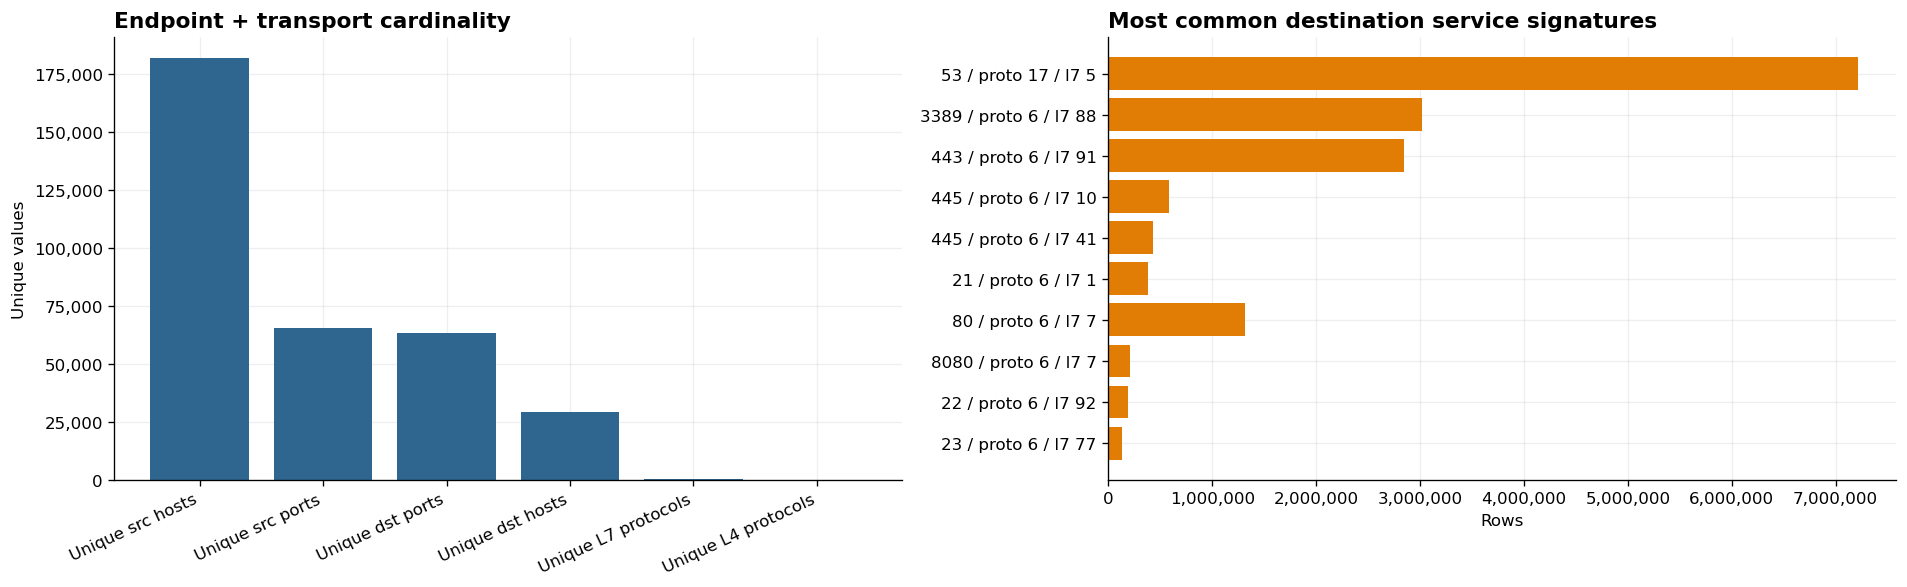

In [46]:
endpoint_transport = dlf.select(
    unique_src_hosts=c("IPV4_SRC_ADDR").n_unique(),
    unique_dst_hosts=c("IPV4_DST_ADDR").n_unique(),
    unique_src_ports=c("L4_SRC_PORT").n_unique(),
    unique_dst_ports=c("L4_DST_PORT").n_unique(),
    unique_protocols=c("PROTOCOL").n_unique(),
    unique_l7_protocols=c("L7_PROTO").n_unique(),
)

top_host_pairs = (
    dlf
    .group_by("IPV4_SRC_ADDR", "IPV4_DST_ADDR", "Label", "Attack")
    .agg(row_count=pl.len())
    .sort("row_count", descending=True)
    .limit(50)
)

top_dst_service_ports = (
    dlf
    .group_by("L4_DST_PORT", "PROTOCOL", "L7_PROTO", "Label", "Attack")
    .agg(row_count=pl.len())
    .sort("row_count", descending=True)
    .limit(50)
)

pair_counts = (
    dlf
    .group_by("IPV4_SRC_ADDR", "IPV4_DST_ADDR")
    .agg(row_count=pl.len())
)

host_pair_shortcut_risk = pair_counts.select(
    unique_host_pairs=pl.len(),
    max_rows_for_single_pair=c("row_count").max(),
    pair_count_quantiles=c("row_count").quantile([0.5, 0.9, 0.99, 0.999]),
)

endpoint_transport_df = collect_df(endpoint_transport)
top_host_pairs_df = collect_df(top_host_pairs)
top_dst_service_ports_df = collect_df(top_dst_service_ports)
host_pair_shortcut_risk_df = collect_df(host_pair_shortcut_risk)

display(endpoint_transport_df)
display(top_host_pairs_df.head(15))
display(host_pair_shortcut_risk_df)

endpoint_metrics = pl.DataFrame({
    "metric": [
        "Unique src hosts",
        "Unique dst hosts",
        "Unique src ports",
        "Unique dst ports",
        "Unique L4 protocols",
        "Unique L7 protocols",
    ],
    "value": list(endpoint_transport_df.row(0)),
}).sort("value", descending=True)

top_service_plot = (
    top_dst_service_ports_df
    .head(12)
    .with_columns(
        service=pl.format(
            "{} / proto {} / l7 {}",
            c("L4_DST_PORT"),
            c("PROTOCOL"),
            c("L7_PROTO"),
        )
    )
    .select("service", "row_count")
    .sort("row_count")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    endpoint_metrics.get_column("metric").to_list(),
    endpoint_metrics.get_column("value").to_list(),
    color="#2F6690",
)
style_axes(axes[0], "Endpoint + transport cardinality", "", "Unique values")
format_count_axis(axes[0], axis="y")
plt.setp(axes[0].get_xticklabels(), rotation=25, ha="right")

axes[1].barh(
    top_service_plot.get_column("service").to_list(),
    top_service_plot.get_column("row_count").to_list(),
    color="#E17C05",
)
style_axes(axes[1], "Most common destination service signatures", "Rows", "")
format_count_axis(axes[1], axis="x")

plt.tight_layout()
plt.show()


#### Traffic volume + counts

metric,row_count
str,i64
"""IN_BYTES null rows""",0
"""OUT_BYTES null rows""",0
"""IN_PKTS null rows""",0
"""OUT_PKTS null rows""",0
"""IN_BYTES zero rows""",0
"""IN_PKTS zero rows""",0
"""Positive IN_BYTES with zero IN…",0
"""Positive OUT_BYTES with zero O…",0
"""OUT_BYTES zero rows""",1975367


field,p50,p99,p999
str,f64,f64,f64
"""IN_BYTES""",146.0,5071.0,24637.0
"""OUT_BYTES""",192.0,32481.0,296086.0
"""IN_PKTS""",3.0,40.0,155.0
"""OUT_PKTS""",2.0,55.0,240.0


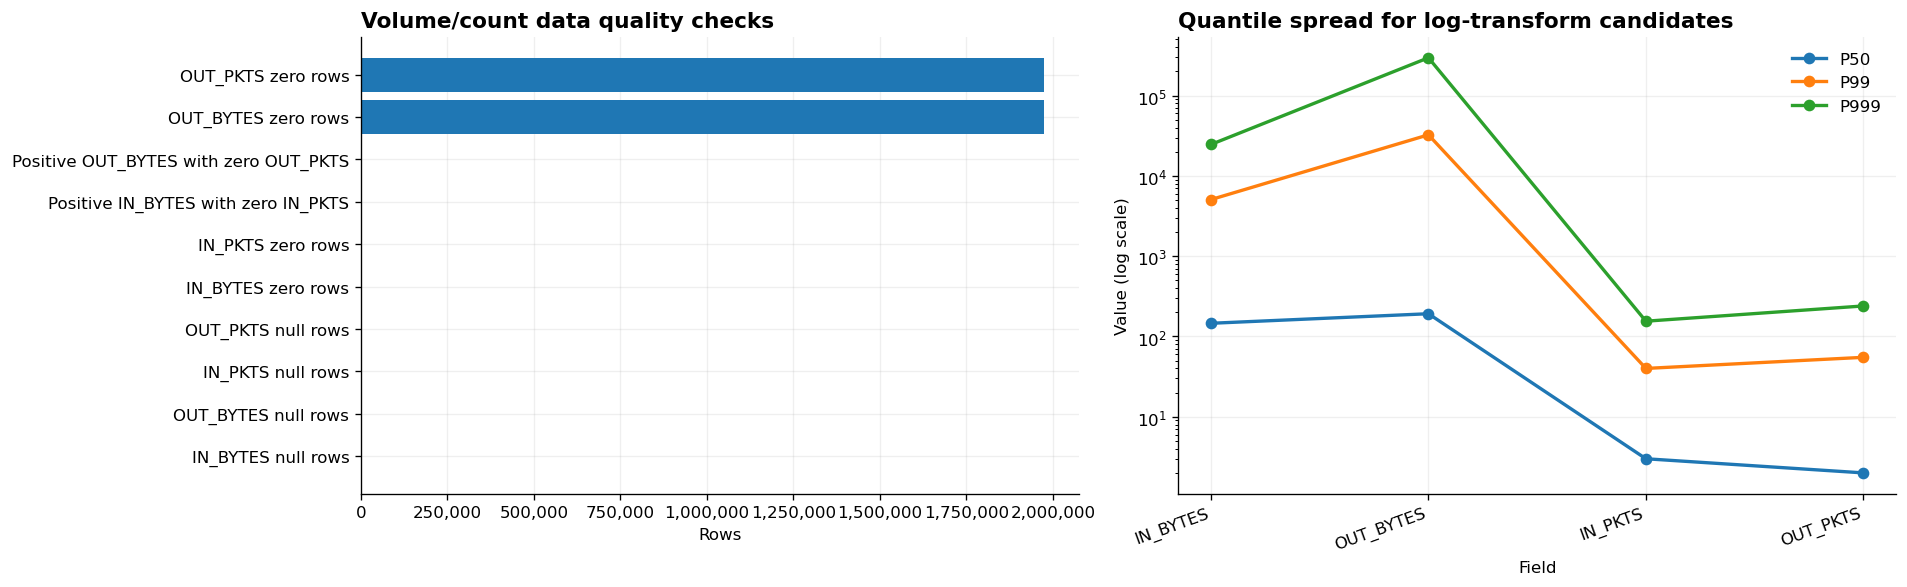

In [47]:
volume_cols = [
    "IN_BYTES", "OUT_BYTES", "IN_PKTS", "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES", "DST_TO_SRC_SECOND_BYTES",
    "SRC_TO_DST_AVG_THROUGHPUT", "DST_TO_SRC_AVG_THROUGHPUT",
]

volume = dlf.select(
    in_bytes=castf("IN_BYTES"),
    out_bytes=castf("OUT_BYTES"),
    in_pkts=castf("IN_PKTS"),
    out_pkts=castf("OUT_PKTS"),
    src_to_dst_second_bytes=castf("SRC_TO_DST_SECOND_BYTES"),
    dst_to_src_second_bytes=castf("DST_TO_SRC_SECOND_BYTES"),
    src_to_dst_avg_throughput=castf("SRC_TO_DST_AVG_THROUGHPUT"),
    dst_to_src_avg_throughput=castf("DST_TO_SRC_AVG_THROUGHPUT"),
)

stats_triplet = lambda col: [
    c(col).min().alias(f"{col}_min"),
    c(col).quantile(0.5).alias(f"{col}_median"),
    c(col).max().alias(f"{col}_max"),
    c(col).quantile([0.9, 0.99, 0.999]).alias(f"{col}_tail_quantiles"),
]

volume_checks = volume.select(
    rows=pl.len(),
    in_bytes_nulls=c("in_bytes").is_null().sum(),
    out_bytes_nulls=c("out_bytes").is_null().sum(),
    in_pkts_nulls=c("in_pkts").is_null().sum(),
    out_pkts_nulls=c("out_pkts").is_null().sum(),
    in_bytes_zero_rows=(c("in_bytes") == 0).sum(),
    out_bytes_zero_rows=(c("out_bytes") == 0).sum(),
    in_pkts_zero_rows=(c("in_pkts") == 0).sum(),
    out_pkts_zero_rows=(c("out_pkts") == 0).sum(),
    in_bytes_with_zero_in_pkts=((c("in_bytes") > 0) & (c("in_pkts") == 0)).sum(),
    out_bytes_with_zero_out_pkts=((c("out_bytes") > 0) & (c("out_pkts") == 0)).sum(),
    *stats_triplet("in_bytes"),
    *stats_triplet("out_bytes"),
    *stats_triplet("in_pkts"),
    *stats_triplet("out_pkts"),
    src_to_dst_second_bytes_quantiles=c("src_to_dst_second_bytes").quantile([0.5, 0.9, 0.99, 0.999]),
    dst_to_src_second_bytes_quantiles=c("dst_to_src_second_bytes").quantile([0.5, 0.9, 0.99, 0.999]),
    src_to_dst_avg_throughput_quantiles=c("src_to_dst_avg_throughput").quantile([0.5, 0.9, 0.99, 0.999]),
    dst_to_src_avg_throughput_quantiles=c("dst_to_src_avg_throughput").quantile([0.5, 0.9, 0.99, 0.999]),
)

log_transform_candidates = pl.concat([
    volume.select(
        pl.lit(src.upper()).alias("field"),
        c(dst).quantile(0.5).alias("p50"),
        c(dst).quantile(0.99).alias("p99"),
        c(dst).quantile(0.999).alias("p999"),
    )
    for src, dst in [
        ("IN_BYTES", "in_bytes"),
        ("OUT_BYTES", "out_bytes"),
        ("IN_PKTS", "in_pkts"),
        ("OUT_PKTS", "out_pkts"),
    ]
])

volume_checks_df = collect_df(volume_checks)
log_transform_candidates_df = collect_df(log_transform_candidates)

volume_metrics = volume_checks_df.row(0, named=True)
volume_anomaly_summary = pl.DataFrame({
    "metric": [
        "IN_BYTES null rows",
        "OUT_BYTES null rows",
        "IN_PKTS null rows",
        "OUT_PKTS null rows",
        "IN_BYTES zero rows",
        "OUT_BYTES zero rows",
        "IN_PKTS zero rows",
        "OUT_PKTS zero rows",
        "Positive IN_BYTES with zero IN_PKTS",
        "Positive OUT_BYTES with zero OUT_PKTS",
    ],
    "row_count": [
        volume_metrics["in_bytes_nulls"],
        volume_metrics["out_bytes_nulls"],
        volume_metrics["in_pkts_nulls"],
        volume_metrics["out_pkts_nulls"],
        volume_metrics["in_bytes_zero_rows"],
        volume_metrics["out_bytes_zero_rows"],
        volume_metrics["in_pkts_zero_rows"],
        volume_metrics["out_pkts_zero_rows"],
        volume_metrics["in_bytes_with_zero_in_pkts"],
        volume_metrics["out_bytes_with_zero_out_pkts"],
    ],
}).sort("row_count")

display(volume_anomaly_summary)
display(log_transform_candidates_df)

fields = log_transform_candidates_df.get_column("field").to_list()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(
    volume_anomaly_summary.get_column("metric").to_list(),
    volume_anomaly_summary.get_column("row_count").to_list(),
)
style_axes(axes[0], "Volume/count data quality checks", "Rows", "")
format_count_axis(axes[0], axis="x")

for column in ["p50", "p99", "p999"]:
    axes[1].plot(
        fields,
        log_transform_candidates_df.get_column(column).to_list(),
        marker="o",
        linewidth=2,
        label=column.upper(),
    )

axes[1].set_yscale("log")
style_axes(axes[1], "Quantile spread for log-transform candidates", "Field", "Value (log scale)")
axes[1].legend(frameon=False)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()


#### Packet size + tcp behaviour

rows,shortest_flow_pkt_negative,longest_flow_pkt_negative,min_ip_pkt_len_negative,max_ip_pkt_len_negative,shortest_gt_longest,min_ip_gt_max_ip,longest_lt_max_ip,bucket_sum_gt_total_pkts,tcp_fields_active_when_not_tcp
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
20115529,0,0,0,0,0,0,0,1099186,0


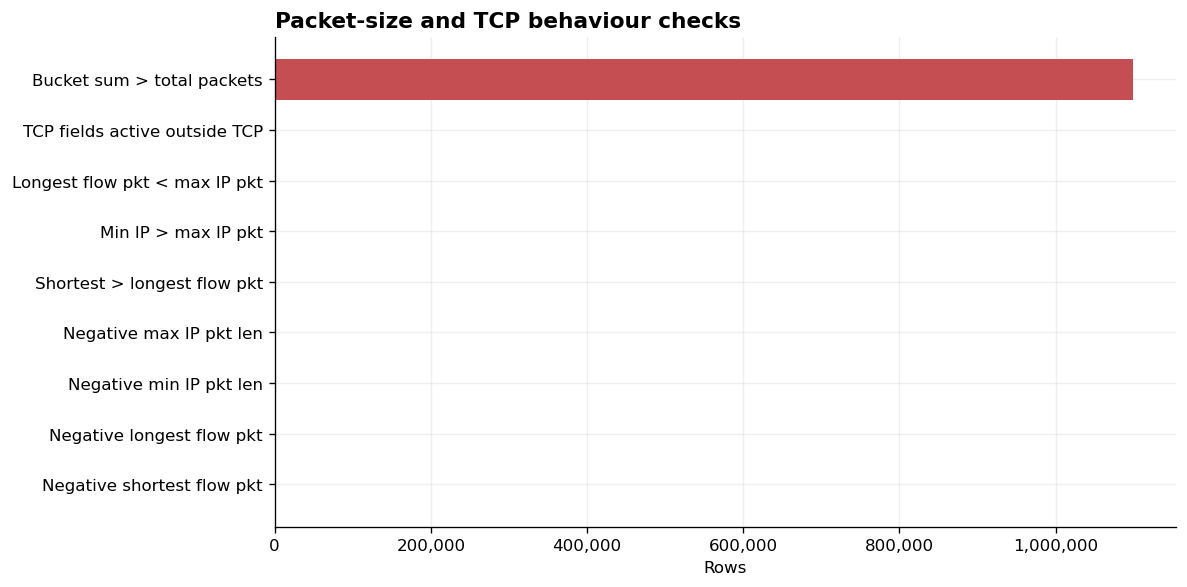

In [48]:
pkt = dlf.select(
    longest_flow_pkt=castf("LONGEST_FLOW_PKT"),
    shortest_flow_pkt=castf("SHORTEST_FLOW_PKT"),
    min_ip_pkt_len=castf("MIN_IP_PKT_LEN"),
    max_ip_pkt_len=castf("MAX_IP_PKT_LEN"),
    in_pkts=castf("IN_PKTS"),
    out_pkts=castf("OUT_PKTS"),
    pkts_0_128=castf("NUM_PKTS_UP_TO_128_BYTES"),
    pkts_128_256=castf("NUM_PKTS_128_TO_256_BYTES"),
    pkts_256_512=castf("NUM_PKTS_256_TO_512_BYTES"),
    pkts_512_1024=castf("NUM_PKTS_512_TO_1024_BYTES"),
    pkts_1024_1514=castf("NUM_PKTS_1024_TO_1514_BYTES"),
    protocol_code=casti("PROTOCOL"),
    tcp_flags=castf("TCP_FLAGS"),
    client_tcp_flags=castf("CLIENT_TCP_FLAGS"),
    server_tcp_flags=castf("SERVER_TCP_FLAGS"),
    tcp_win_max_in=castf("TCP_WIN_MAX_IN"),
    tcp_win_max_out=castf("TCP_WIN_MAX_OUT"),
)

bucket_sum = (
    c("pkts_0_128") + c("pkts_128_256") + c("pkts_256_512")
    + c("pkts_512_1024") + c("pkts_1024_1514")
)
total_pkts = c("in_pkts") + c("out_pkts")
all_bucket_inputs_present = (
    c("pkts_0_128").is_not_null()
    & c("pkts_128_256").is_not_null()
    & c("pkts_256_512").is_not_null()
    & c("pkts_512_1024").is_not_null()
    & c("pkts_1024_1514").is_not_null()
    & c("in_pkts").is_not_null()
    & c("out_pkts").is_not_null()
)

tcp_active = (
    (c("tcp_flags").fill_null(0) != 0)
    | (c("client_tcp_flags").fill_null(0) != 0)
    | (c("server_tcp_flags").fill_null(0) != 0)
    | (c("tcp_win_max_in").fill_null(0) != 0)
    | (c("tcp_win_max_out").fill_null(0) != 0)
)

pkt_tcp_checks = pkt.select(
    rows=pl.len(),
    shortest_flow_pkt_negative=(c("shortest_flow_pkt") < 0).sum(),
    longest_flow_pkt_negative=(c("longest_flow_pkt") < 0).sum(),
    min_ip_pkt_len_negative=(c("min_ip_pkt_len") < 0).sum(),
    max_ip_pkt_len_negative=(c("max_ip_pkt_len") < 0).sum(),
    shortest_gt_longest=(c("shortest_flow_pkt") > c("longest_flow_pkt")).sum(),
    min_ip_gt_max_ip=(c("min_ip_pkt_len") > c("max_ip_pkt_len")).sum(),
    longest_lt_max_ip=(c("longest_flow_pkt") < c("max_ip_pkt_len")).sum(),
    bucket_sum_gt_total_pkts=((bucket_sum > total_pkts) & all_bucket_inputs_present).sum(),
    tcp_fields_active_when_not_tcp=((c("protocol_code") != 6) & tcp_active).sum(),
)

pkt_tcp_checks_df = collect_df(pkt_tcp_checks)
pkt_metrics = pkt_tcp_checks_df.row(0, named=True)

pkt_anomaly_summary = pl.DataFrame({
    "metric": [
        "Negative shortest flow pkt",
        "Negative longest flow pkt",
        "Negative min IP pkt len",
        "Negative max IP pkt len",
        "Shortest > longest flow pkt",
        "Min IP > max IP pkt",
        "Longest flow pkt < max IP pkt",
        "Bucket sum > total packets",
        "TCP fields active outside TCP",
    ],
    "row_count": [
        pkt_metrics["shortest_flow_pkt_negative"],
        pkt_metrics["longest_flow_pkt_negative"],
        pkt_metrics["min_ip_pkt_len_negative"],
        pkt_metrics["max_ip_pkt_len_negative"],
        pkt_metrics["shortest_gt_longest"],
        pkt_metrics["min_ip_gt_max_ip"],
        pkt_metrics["longest_lt_max_ip"],
        pkt_metrics["bucket_sum_gt_total_pkts"],
        pkt_metrics["tcp_fields_active_when_not_tcp"],
    ],
}).sort("row_count")

display(pkt_tcp_checks_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    pkt_anomaly_summary.get_column("metric").to_list(),
    pkt_anomaly_summary.get_column("row_count").to_list(),
    color="#C44E52",
)
style_axes(ax, "Packet-size and TCP behaviour checks", "Rows", "")
format_count_axis(ax, axis="x")

plt.tight_layout()
plt.show()


#### Protocol-specific sparse fields

icmp_type_outside_icmp,icmp_ipv4_type_outside_icmp,dns_query_id_outside_dns_like_context,dns_query_type_outside_dns_like_context,dns_ttl_answer_outside_dns_like_context,ftp_ret_code_outside_ftp_like_context
u32,u32,u32,u32,u32,u32
20085445,20085445,17050919,17050919,17050919,20115529


field,null_rows,zero_rows,nonzero_rows
str,u32,u32,u32
"""ICMP_TYPE""",0,18527820,1587709
"""ICMP_IPV4_TYPE""",0,18527821,1587708
"""DNS_QUERY_ID""",0,12688819,7426710
"""DNS_QUERY_TYPE""",0,12688819,7426710
"""DNS_TTL_ANSWER""",0,12844163,7271366
"""FTP_COMMAND_RET_CODE""",0,20115529,0


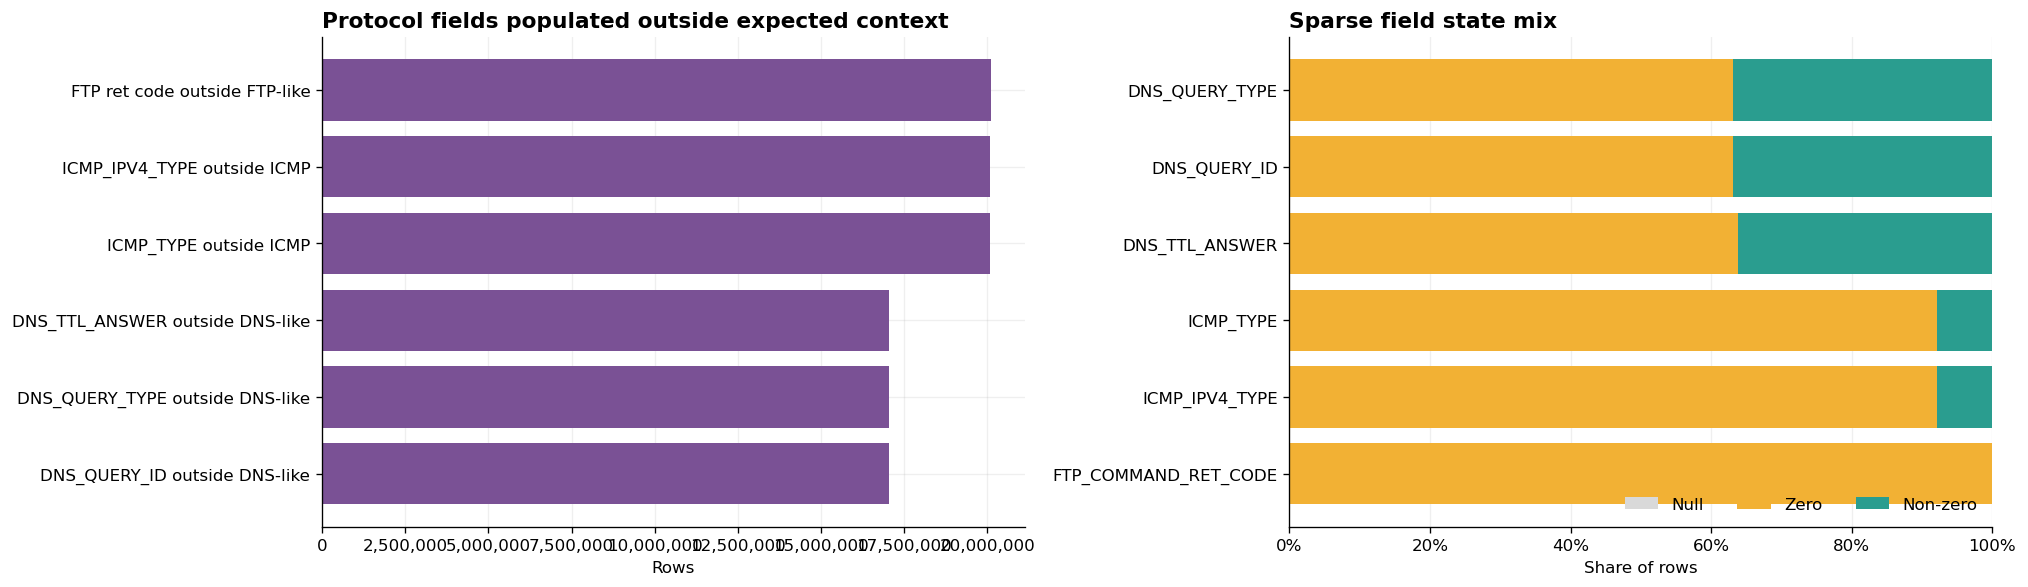

In [49]:
proto = dlf.select(
    protocol_code=casti("PROTOCOL"),
    l7_proto=casti("L7_PROTO"),
    ICMP_TYPE=c("ICMP_TYPE"),
    ICMP_IPV4_TYPE=c("ICMP_IPV4_TYPE"),
    DNS_QUERY_ID=c("DNS_QUERY_ID"),
    DNS_QUERY_TYPE=c("DNS_QUERY_TYPE"),
    DNS_TTL_ANSWER=c("DNS_TTL_ANSWER"),
    FTP_COMMAND_RET_CODE=c("FTP_COMMAND_RET_CODE"),
)

dns_like = c("l7_proto").fill_null(-1).is_in([7])
ftp_like = c("l7_proto").fill_null(-1).is_in([117])

protocol_specific_outside_context = proto.select(
    icmp_type_outside_icmp=(c("ICMP_TYPE").is_not_null() & (c("protocol_code") != 1)).sum(),
    icmp_ipv4_type_outside_icmp=(c("ICMP_IPV4_TYPE").is_not_null() & (c("protocol_code") != 1)).sum(),
    dns_query_id_outside_dns_like_context=(c("DNS_QUERY_ID").is_not_null() & ~dns_like).sum(),
    dns_query_type_outside_dns_like_context=(c("DNS_QUERY_TYPE").is_not_null() & ~dns_like).sum(),
    dns_ttl_answer_outside_dns_like_context=(c("DNS_TTL_ANSWER").is_not_null() & ~dns_like).sum(),
    ftp_ret_code_outside_ftp_like_context=(c("FTP_COMMAND_RET_CODE").is_not_null() & ~ftp_like).sum(),
)

sparse_fields = [
    "ICMP_TYPE",
    "ICMP_IPV4_TYPE",
    "DNS_QUERY_ID",
    "DNS_QUERY_TYPE",
    "DNS_TTL_ANSWER",
    "FTP_COMMAND_RET_CODE",
]

sparse_zero_nonzero = pl.concat([
    dlf.select(
        pl.lit(field).alias("field"),
        c(field).is_null().sum().alias("null_rows"),
        castf(field).eq(0).sum().alias("zero_rows"),
        castf(field).ne(0).sum().alias("nonzero_rows"),
    )
    for field in sparse_fields
])

protocol_specific_outside_context_df = collect_df(protocol_specific_outside_context)
sparse_zero_nonzero_df = collect_df(sparse_zero_nonzero)

display(protocol_specific_outside_context_df)
display(sparse_zero_nonzero_df)

context_metrics = protocol_specific_outside_context_df.row(0, named=True)
context_plot = pl.DataFrame({
    "metric": [
        "ICMP_TYPE outside ICMP",
        "ICMP_IPV4_TYPE outside ICMP",
        "DNS_QUERY_ID outside DNS-like",
        "DNS_QUERY_TYPE outside DNS-like",
        "DNS_TTL_ANSWER outside DNS-like",
        "FTP ret code outside FTP-like",
    ],
    "row_count": [
        context_metrics["icmp_type_outside_icmp"],
        context_metrics["icmp_ipv4_type_outside_icmp"],
        context_metrics["dns_query_id_outside_dns_like_context"],
        context_metrics["dns_query_type_outside_dns_like_context"],
        context_metrics["dns_ttl_answer_outside_dns_like_context"],
        context_metrics["ftp_ret_code_outside_ftp_like_context"],
    ],
}).sort("row_count")

sparse_state_plot = (
    sparse_zero_nonzero_df
    .with_columns(
        total_rows=pl.sum_horizontal("null_rows", "zero_rows", "nonzero_rows")
    )
    .with_columns(
        null_pct=c("null_rows") / c("total_rows"),
        zero_pct=c("zero_rows") / c("total_rows"),
        nonzero_pct=c("nonzero_rows") / c("total_rows"),
    )
    .sort("nonzero_rows")
)
fields = sparse_state_plot.get_column("field").to_list()
null_pct = sparse_state_plot.get_column("null_pct").to_list()
zero_pct = sparse_state_plot.get_column("zero_pct").to_list()
nonzero_pct = sparse_state_plot.get_column("nonzero_pct").to_list()
zero_left = null_pct
nonzero_left = [n + z for n, z in zip(null_pct, zero_pct)]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].barh(
    context_plot.get_column("metric").to_list(),
    context_plot.get_column("row_count").to_list(),
    color="#7A5195",
)
style_axes(axes[0], "Protocol fields populated outside expected context", "Rows", "")
format_count_axis(axes[0], axis="x")

axes[1].barh(fields, null_pct, color="#D9D9D9", label="Null")
axes[1].barh(fields, zero_pct, left=zero_left, color="#F2B134", label="Zero")
axes[1].barh(fields, nonzero_pct, left=nonzero_left, color="#2A9D8F", label="Non-zero")

style_axes(axes[1], "Sparse field state mix", "Share of rows", "")
format_pct_axis(axes[1], axis="x")
axes[1].legend(frameon=False, ncols=3, loc="lower right")

plt.tight_layout()
plt.show()

#### Special treatment columns

In [50]:
schema = dlf.collect_schema()
columns = pl.LazyFrame({
    "column_name": schema.names(),
    "data_type": [str(dt) for dt in schema.dtypes()],
})

identifier_like = ["IPV4_SRC_ADDR", "IPV4_DST_ADDR", "L4_SRC_PORT", "L4_DST_PORT", "DNS_QUERY_ID"]
leak_prone = ["FLOW_START_MILLISECONDS", "FLOW_END_MILLISECONDS", "Label", "Attack"]
protocol_specific = [
    "ICMP_TYPE", "ICMP_IPV4_TYPE", "DNS_QUERY_ID", "DNS_QUERY_TYPE",
    "DNS_TTL_ANSWER", "FTP_COMMAND_RET_CODE",
    "TCP_FLAGS", "CLIENT_TCP_FLAGS", "SERVER_TCP_FLAGS",
    "TCP_WIN_MAX_IN", "TCP_WIN_MAX_OUT",
]
special_handling = [
    "FLOW_START_MILLISECONDS", "FLOW_END_MILLISECONDS",
    "IPV4_SRC_ADDR", "IPV4_DST_ADDR",
    "L4_SRC_PORT", "L4_DST_PORT",
    "DNS_QUERY_ID", "Label", "Attack",
]

special_treatment_columns = (
    columns
    .select(
        "column_name",
        "data_type",
        c("column_name").is_in(identifier_like).alias("identifier_like"),
        c("column_name").is_in(leak_prone).alias("leak_prone"),
        c("column_name").is_in(protocol_specific).alias("protocol_specific"),
        pl.when(c("column_name").is_in(special_handling))
        .then(pl.lit("special handling required"))
        .otherwise(pl.lit("standard candidate"))
        .alias("treatment_note"),
    )
    .sort("column_name")
)

display(special_treatment_columns.collect(engine="streaming"))

column_name,data_type,identifier_like,leak_prone,protocol_specific,treatment_note
str,str,bool,bool,bool,str
"""Attack""","""String""",false,true,false,"""special handling required"""
"""CLIENT_TCP_FLAGS""","""Int64""",false,false,true,"""standard candidate"""
"""DNS_QUERY_ID""","""Int64""",true,false,true,"""special handling required"""
"""DNS_QUERY_TYPE""","""Int64""",false,false,true,"""standard candidate"""
"""DNS_TTL_ANSWER""","""Int64""",false,false,true,"""standard candidate"""
…,…,…,…,…,…
"""SRC_TO_DST_IAT_STDDEV""","""Int64""",false,false,false,"""standard candidate"""
"""SRC_TO_DST_SECOND_BYTES""","""Int64""",false,false,false,"""standard candidate"""
"""TCP_FLAGS""","""Int64""",false,false,true,"""standard candidate"""


### Label

In [51]:
c = pl.col
norm = lambda x: c(x).cast(pl.Utf8, strict=False).str.strip_chars().str.to_lowercase()

labels = dlf.select(
    label=norm("Label"),
    attack=norm("Attack"),
    flow_day=pl.from_epoch(
        c("FLOW_START_MILLISECONDS").cast(pl.Int64, strict=False),
        time_unit="ms",
    ).dt.date(),
)

benign_attack_names = {"benign"}

#### Validate Label vs Attack

relation,row_count,attacks,labels
str,u32,list[str],list[str]
"""label_malicious_attack_benign""",17514626,"[""benign""]","[""0""]"
"""malicious_consistent""",2600903,"[""bot"", ""brute_force_-web"", … ""ssh-bruteforce""]","[""1""]"


label,attack,relation,row_count
str,str,str,u32
"""0""","""benign""","""label_malicious_attack_benign""",17514626


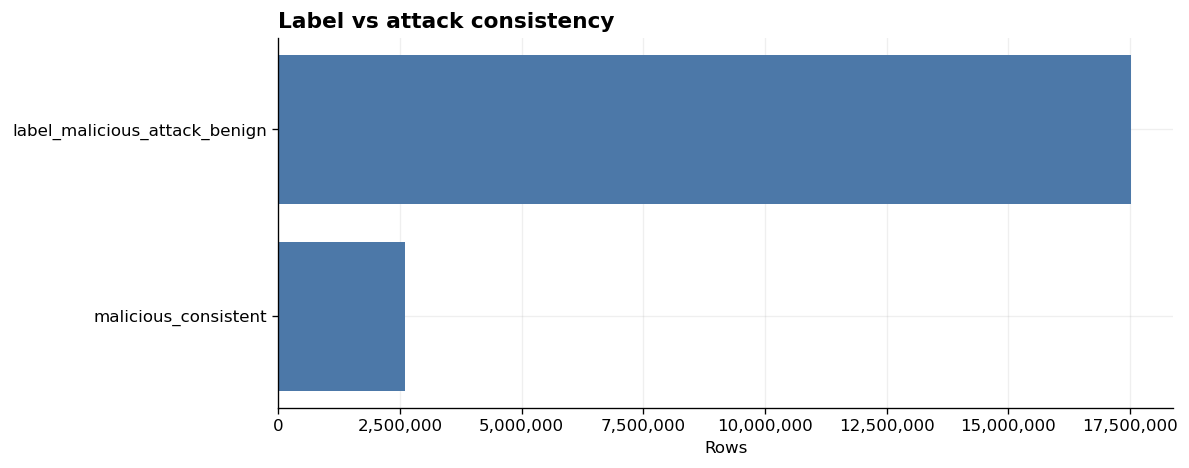

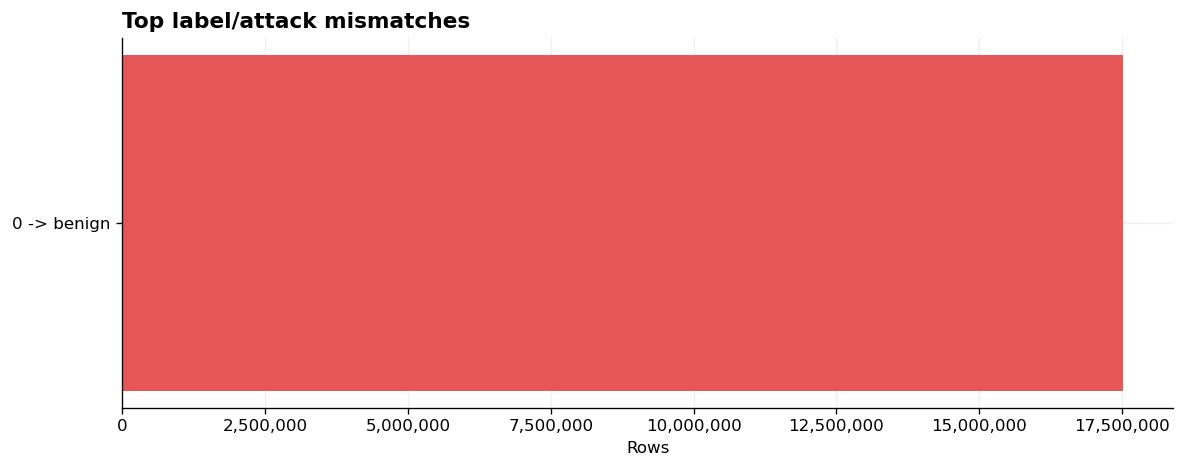

In [52]:
label_attack_consistency = (
    labels
    .with_columns(
        is_benign_label=c("label") == "benign",
        is_benign_attack=c("attack").is_in(benign_attack_names),
    )
    .with_columns(
        relation=(
            pl.when(c("is_benign_label") & c("is_benign_attack")).then(pl.lit("benign_consistent"))
            .when((~c("is_benign_label")) & (~c("is_benign_attack"))).then(pl.lit("malicious_consistent"))
            .when(c("is_benign_label") & (~c("is_benign_attack"))).then(pl.lit("label_benign_attack_nonbenign"))
            .otherwise(pl.lit("label_malicious_attack_benign"))
        )
    )
)

label_attack_report = (
    label_attack_consistency
    .group_by("relation")
    .agg(
        row_count=pl.len(),
        attacks=c("attack").drop_nulls().unique().sort(),
        labels=c("label").drop_nulls().unique().sort(),
    )
    .sort("row_count", descending=True)
)

label_attack_mismatches = (
    label_attack_consistency
    .filter(~c("relation").is_in(["benign_consistent", "malicious_consistent"]))
    .group_by("label", "attack", "relation")
    .agg(row_count=pl.len())
    .sort("row_count", descending=True)
)

label_attack_report_df = collect_df(label_attack_report)
label_attack_mismatches_df = collect_df(label_attack_mismatches)

display(label_attack_report_df)
if label_attack_mismatches_df.height > 0:
    display(label_attack_mismatches_df)

relation_plot = label_attack_report_df.select("relation", "row_count").sort("row_count")

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    relation_plot.get_column("relation").to_list(),
    relation_plot.get_column("row_count").to_list(),
    color="#4C78A8",
)
style_axes(ax, "Label vs attack consistency", "Rows", "")
format_count_axis(ax, axis="x")

plt.tight_layout()
plt.show()

if label_attack_mismatches_df.height > 0:
    mismatch_plot = (
        label_attack_mismatches_df
        .head(10)
        .with_columns(pair=pl.format("{} -> {}", c("label"), c("attack")))
        .select("pair", "row_count")
        .sort("row_count")
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(
        mismatch_plot.get_column("pair").to_list(),
        mismatch_plot.get_column("row_count").to_list(),
        color="#E45756",
    )
    style_axes(ax, "Top label/attack mismatches", "Rows", "")
    format_count_axis(ax, axis="x")
    plt.tight_layout()
    plt.show()


#### Class-distribution

label,row_count,pct
str,u32,f64
"""0""",17514626,0.870702
"""1""",2600903,0.129298


attack,row_count,pct
str,u32,f64
"""ssh-bruteforce""",188474,0.00937
"""infilteration""",188152,0.009354
"""dos_attacks-slowhttptest""",105550,0.005247
"""dos_attacks-hulk""",100076,0.004975
"""dos_attacks-goldeneye""",61300,0.003047
"""dos_attacks-slowloris""",36040,0.001792
"""ddos_attack-loic-udp""",3450,0.000172
"""brute_force_-web""",1618,0.00008
"""brute_force_-xss""",480,0.000024


attack,row_count,pct
str,u32,f64


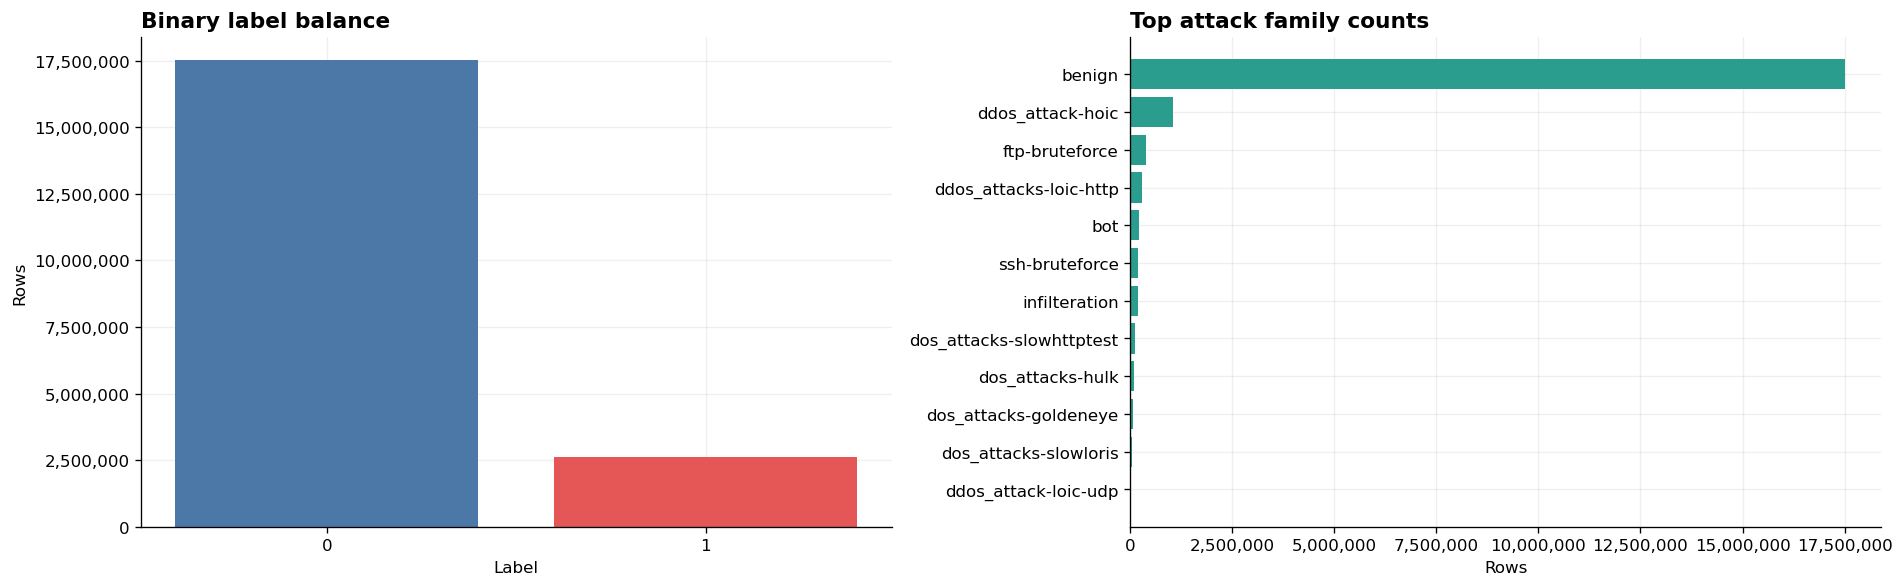

In [53]:
binary_balance = (
    labels
    .group_by("label")
    .agg(row_count=pl.len())
    .with_columns(pct=(c("row_count") / c("row_count").sum()))
    .sort("row_count", descending=True)
)

attack_counts = (
    labels
    .group_by("attack")
    .agg(row_count=pl.len())
    .with_columns(pct=(c("row_count") / c("row_count").sum()))
    .sort("row_count", descending=True)
)

long_tail_threshold = 0.01
low_support_threshold = 50

long_tail_attack_families = attack_counts.filter(c("pct") < long_tail_threshold)
low_support_attack_families = attack_counts.filter(c("row_count") < low_support_threshold)

binary_balance_df = collect_df(binary_balance)
attack_counts_df = collect_df(attack_counts)
long_tail_attack_families_df = collect_df(long_tail_attack_families)
low_support_attack_families_df = collect_df(low_support_attack_families)

display(binary_balance_df)
display(long_tail_attack_families_df)
display(low_support_attack_families_df)

top_attack_plot = attack_counts_df.head(12).sort("row_count")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    binary_balance_df.get_column("label").to_list(),
    binary_balance_df.get_column("row_count").to_list(),
    color=["#4C78A8", "#E45756"],
)
style_axes(axes[0], "Binary label balance", "Label", "Rows")
format_count_axis(axes[0], axis="y")

axes[1].barh(
    top_attack_plot.get_column("attack").to_list(),
    top_attack_plot.get_column("row_count").to_list(),
    color="#2A9D8F",
)
style_axes(axes[1], "Top attack family counts", "Rows", "")
format_count_axis(axes[1], axis="x")

plt.tight_layout()
plt.show()


#### Temporal Label

attack,days_present,first_day,last_day,total_rows
str,u32,date,date,u32
"""sql_injection""",1,2018-02-22,2018-02-22,440
"""brute_force_-xss""",1,2018-02-22,2018-02-22,480
"""brute_force_-web""",1,2018-02-22,2018-02-22,1618
"""ddos_attack-loic-udp""",1,2018-02-21,2018-02-21,3450
"""dos_attacks-slowloris""",1,2018-02-15,2018-02-15,36040
…,…,…,…,…
"""ddos_attacks-loic-http""",1,2018-02-20,2018-02-20,288589
"""ftp-bruteforce""",1,2018-02-14,2018-02-14,386720
"""ddos_attack-hoic""",1,2018-02-21,2018-02-21,1032311


attack,days_present,first_day,last_day,total_rows
str,u32,date,date,u32
"""sql_injection""",1,2018-02-22,2018-02-22,440
"""brute_force_-xss""",1,2018-02-22,2018-02-22,480
"""brute_force_-web""",1,2018-02-22,2018-02-22,1618
"""ddos_attack-loic-udp""",1,2018-02-21,2018-02-21,3450
"""dos_attacks-slowloris""",1,2018-02-15,2018-02-15,36040
…,…,…,…,…
"""bot""",1,2018-03-02,2018-03-02,207703
"""ddos_attacks-loic-http""",1,2018-02-20,2018-02-20,288589
"""ftp-bruteforce""",1,2018-02-14,2018-02-14,386720


flow_day,rows,benign_rows,attack_rows,benign_pct,attack_pct
date,u32,u32,u32,f64,f64


flow_day,rows,benign_rows,attack_rows,benign_pct,attack_pct
date,u32,u32,u32,f64,f64
2018-02-14,2138838,0,2138838,0.0,1.0
2018-02-15,1665321,0,1665321,0.0,1.0
2018-02-16,1784129,0,1784129,0.0,1.0
2018-02-20,1829859,0,1829859,0.0,1.0
2018-02-21,2712803,0,2712803,0.0,1.0
…,…,…,…,…,…
2018-02-23,1933002,0,1933002,0.0,1.0
2018-02-27,828,0,828,0.0,1.0
2018-02-28,2032727,0,2032727,0.0,1.0


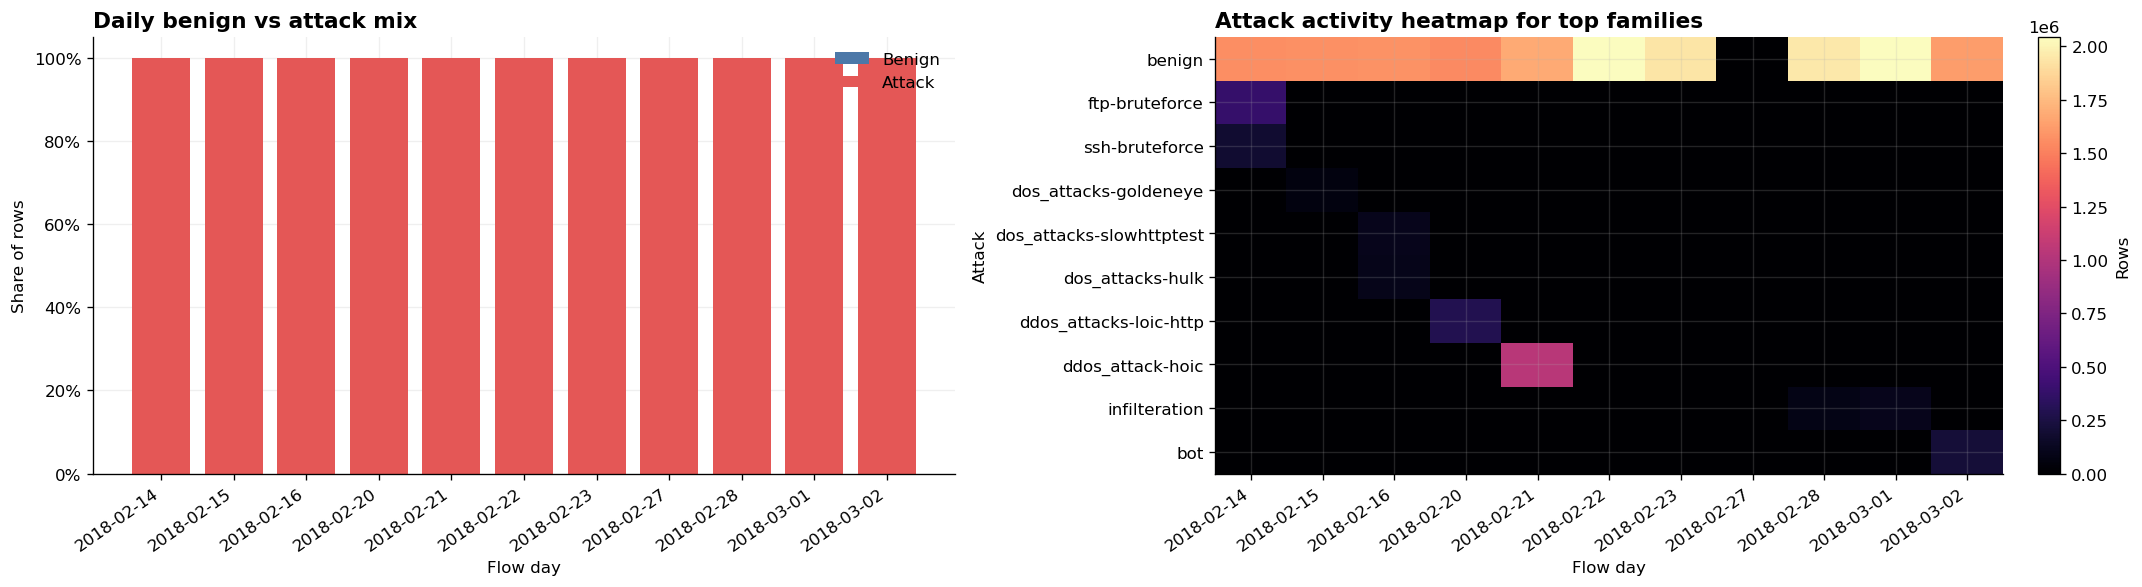

In [54]:
attack_counts_by_day = (
    labels
    .group_by("flow_day", "attack")
    .agg(row_count=pl.len())
    .sort(["flow_day", "row_count"], descending=[False, True])
)

attack_day_span = (
    attack_counts_by_day
    .group_by("attack")
    .agg(
        days_present=pl.len(),
        first_day=c("flow_day").min(),
        last_day=c("flow_day").max(),
        total_rows=c("row_count").sum(),
    )
    .sort(["days_present", "total_rows"])
)

narrow_window_attacks = attack_day_span.filter(c("days_present") <= 2)

day_binary_mix = (
    labels
    .with_columns(is_benign=c("label") == "benign")
    .group_by("flow_day")
    .agg(
        rows=pl.len(),
        benign_rows=c("is_benign").sum(),
    )
    .with_columns(
        attack_rows=c("rows") - c("benign_rows"),
        benign_pct=c("benign_rows") / c("rows"),
        attack_pct=(c("rows") - c("benign_rows")) / c("rows"),
    )
    .sort("flow_day")
)

mostly_benign_days = day_binary_mix.filter(c("benign_pct") >= 0.95)
mostly_attack_days = day_binary_mix.filter(c("attack_pct") >= 0.95)

attack_counts_by_day_df = collect_df(attack_counts_by_day)
attack_day_span_df = collect_df(attack_day_span)
narrow_window_attacks_df = collect_df(narrow_window_attacks)
day_binary_mix_df = collect_df(day_binary_mix)
mostly_benign_days_df = collect_df(mostly_benign_days)
mostly_attack_days_df = collect_df(mostly_attack_days)

display(attack_day_span_df)
display(narrow_window_attacks_df)
display(mostly_benign_days_df)
display(mostly_attack_days_df)

day_binary_plot = day_binary_mix_df.with_columns(flow_day_str=c("flow_day").cast(pl.Utf8))
top_attacks = (
    attack_day_span_df
    .sort("total_rows", descending=True)
    .head(10)
    .get_column("attack")
    .to_list()
)
attack_heatmap_df = (
    attack_counts_by_day_df
    .filter(c("attack").is_in(top_attacks))
    .with_columns(flow_day_str=c("flow_day").cast(pl.Utf8))
    .select("attack", "flow_day_str", "row_count")
    .pivot(index="attack", on="flow_day_str", values="row_count", aggregate_function="sum")
    .fill_null(0)
)
day_columns = [col for col in attack_heatmap_df.columns if col != "attack"]
heatmap_matrix = attack_heatmap_df.select(day_columns).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(
    day_binary_plot.get_column("flow_day_str").to_list(),
    day_binary_plot.get_column("benign_pct").to_list(),
    color="#4C78A8",
    label="Benign",
)
axes[0].bar(
    day_binary_plot.get_column("flow_day_str").to_list(),
    day_binary_plot.get_column("attack_pct").to_list(),
    bottom=day_binary_plot.get_column("benign_pct").to_list(),
    color="#E45756",
    label="Attack",
)
style_axes(axes[0], "Daily benign vs attack mix", "Flow day", "Share of rows")
format_pct_axis(axes[0], axis="y")
axes[0].legend(frameon=False)
plt.setp(axes[0].get_xticklabels(), rotation=35, ha="right")

im = axes[1].imshow(heatmap_matrix, aspect="auto", cmap="magma")
axes[1].set_yticks(range(attack_heatmap_df.height), labels=attack_heatmap_df.get_column("attack").to_list())
axes[1].set_xticks(range(len(day_columns)), labels=day_columns)
style_axes(axes[1], "Attack activity heatmap for top families", "Flow day", "Attack")
plt.setp(axes[1].get_xticklabels(), rotation=35, ha="right")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Rows")

plt.tight_layout()
plt.show()


#### Label views

coarse_family,row_count
str,u32
"""benign""",17514626
"""other_attack""",2393200
"""botnet""",207703


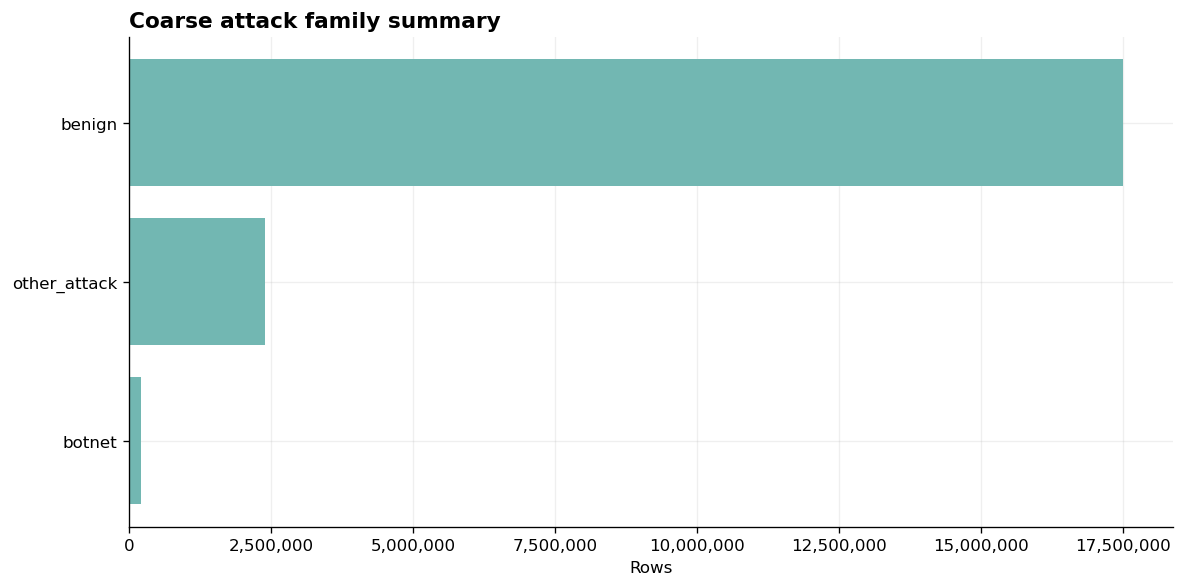

In [56]:
binary_target_view = labels.select("label")
fine_grained_family_view = labels.select("attack")

coarse_family_map = {
    "benign": "benign",
    "bot": "botnet",
    "ddos": "dos_ddos",
    "dos": "dos_ddos",
    "ftp-patator": "bruteforce",
    "ssh-patator": "bruteforce",
    "brute force -web": "bruteforce",
    "brute force -xss": "bruteforce",
    "sql injection": "web_attack",
    "xss": "web_attack",
    "infiltration": "infiltration",
    "heartbleed": "exploitation",
    "portscan": "reconnaissance",
    "scan": "reconnaissance",
}

coarse_family_view = (
    labels
    .with_columns(
        coarse_family=pl.col("attack").replace_strict(
            coarse_family_map,
            default="other_attack",
        )
    )
    .select("label", "attack", "coarse_family", "flow_day")
)

coarse_family_counts = (
    coarse_family_view
    .group_by("coarse_family")
    .agg(row_count=pl.len())
    .sort("row_count", descending=True)
)

coarse_family_counts_df = collect_df(coarse_family_counts)
coarse_family_plot = coarse_family_counts_df.sort("row_count")

display(coarse_family_counts_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    coarse_family_plot.get_column("coarse_family").to_list(),
    coarse_family_plot.get_column("row_count").to_list(),
    color="#72B7B2",
)
style_axes(ax, "Coarse attack family summary", "Rows", "")
format_count_axis(ax, axis="x")

plt.tight_layout()
plt.show()


## Dataset Integrity

In [58]:
c = pl.col
casti = lambda x: c(x).cast(pl.Int64, strict=False)
norms = lambda x: c(x).cast(pl.Utf8, strict=False).str.strip_chars()

In [59]:
inspection_only_fields = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "IPV4_SRC_ADDR",
    "IPV4_DST_ADDR",
    "L4_SRC_PORT",
    "L4_DST_PORT",
    "DNS_QUERY_ID",
    "Label",
    "Attack",
]

schema_names = dlf.collect_schema().names()

typed = dlf.select(
    flow_start_ms=casti("FLOW_START_MILLISECONDS"),
    flow_end_ms=casti("FLOW_END_MILLISECONDS"),
    flow_duration_ms=casti("FLOW_DURATION_MILLISECONDS"),
    flow_day=pl.from_epoch(casti("FLOW_START_MILLISECONDS"), time_unit="ms").dt.date(),
    src_addr=norms("IPV4_SRC_ADDR"),
    dst_addr=norms("IPV4_DST_ADDR"),
    src_port=casti("L4_SRC_PORT"),
    dst_port=casti("L4_DST_PORT"),
    protocol=casti("PROTOCOL"),
    l7_proto=casti("L7_PROTO"),
    in_bytes=casti("IN_BYTES"),
    out_bytes=casti("OUT_BYTES"),
    in_pkts=casti("IN_PKTS"),
    out_pkts=casti("OUT_PKTS"),
    dns_query_id=casti("DNS_QUERY_ID"),
    label=norms("Label").str.to_lowercase(),
    attack=norms("Attack").str.to_lowercase(),
)

dup_summary = lambda lf, cols: (
    lf.group_by(cols)
    .agg(row_count=pl.len())
    .select(
        duplicate_groups=(c("row_count") > 1).sum(),
        duplicate_rows=c("row_count").filter(c("row_count") > 1).sum() - (c("row_count") > 1).sum(),
        max_group_size=c("row_count").max(),
    )
)

dup_groups = lambda lf, cols: (
    lf.group_by(cols)
    .agg(row_count=pl.len())
    .filter(c("row_count") > 1)
    .sort("row_count", descending=True)
)

### Duplicate checks

In [60]:
exact_duplicate_summary = dup_summary(dlf, schema_names)
exact_duplicate_groups = dup_groups(dlf, schema_names)

non_inspection_cols = [col for col in schema_names if col not in inspection_only_fields]
non_inspection_duplicate_summary = dup_summary(dlf, non_inspection_cols)
non_inspection_duplicate_groups = dup_groups(dlf, non_inspection_cols)

flow_sig_cols = [
    "flow_day",
    "src_addr",
    "dst_addr",
    "src_port",
    "dst_port",
    "protocol",
    "l7_proto",
    "flow_duration_ms",
    "in_bytes",
    "out_bytes",
    "in_pkts",
    "out_pkts",
]

near_duplicate_summary = (
    typed
    .group_by(flow_sig_cols)
    .agg(
        row_count=pl.len(),
        labels=c("label").drop_nulls().unique().sort(),
        attacks=c("attack").drop_nulls().unique().sort(),
    )
    .select(
        duplicate_groups=(c("row_count") > 1).sum(),
        duplicate_rows=c("row_count").filter(c("row_count") > 1).sum() - (c("row_count") > 1).sum(),
        max_group_size=c("row_count").max(),
    )
)

near_duplicate_groups = (
    typed
    .group_by(flow_sig_cols)
    .agg(
        row_count=pl.len(),
        labels=c("label").drop_nulls().unique().sort(),
        attacks=c("attack").drop_nulls().unique().sort(),
    )
    .filter(c("row_count") > 1)
    .sort("row_count", descending=True)
)

display(collect_df(exact_duplicate_summary))
display(collect_df(non_inspection_duplicate_summary))
display(collect_df(near_duplicate_summary))
display(collect_df(exact_duplicate_groups.limit(20)))
display(collect_df(non_inspection_duplicate_groups.limit(20)))
display(collect_df(near_duplicate_groups.limit(20)))


duplicate_groups,duplicate_rows,max_group_size
u32,u32,u32
628200,628474,3


duplicate_groups,duplicate_rows,max_group_size
u32,u32,u32
831468,11309837,703193


duplicate_groups,duplicate_rows,max_group_size
u32,u32,u32
524787,1199434,839


FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,row_count
i64,i64,str,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,u32
1519913659481,1519913659481,"""172.31.69.13""",59149,"""172.31.69.7""",53,6,5,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
1519913659515,1519913659515,"""172.31.69.13""",59149,"""172.31.69.7""",1048,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
1519913659493,1519913659493,"""172.31.69.13""",59149,"""172.31.69.7""",19780,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
1519913659533,1519913659533,"""172.31.69.13""",59149,"""172.31.69.7""",16016,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
1519913659532,1519913659532,"""172.31.69.13""",59149,"""172.31.69.7""",911,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1519913659554,1519913659554,"""172.31.69.13""",59149,"""172.31.69.7""",27000,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
1519913659555,1519913659555,"""172.31.69.13""",59149,"""172.31.69.7""",497,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3
1519913659536,1519913659536,"""172.31.69.13""",59149,"""172.31.69.7""",3017,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""Infilteration""",3


PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,row_count
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,u32
6,88,40,1,0,0,20,20,0,1,0,0,0,0,40,40,0,40,0,0,0,0,0,0,320000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,703193
6,1,60,1,40,1,22,2,20,1,0,0,0,0,60,40,40,60,0,0,0,0,0,0,480000,320000,2,0,0,0,0,26883,0,0,0,0,0,0,0,0,0,0,0,0,0,0,492330
6,0,40,1,0,0,2,2,0,1,0,0,0,0,40,40,0,40,0,0,0,0,0,0,320000,0,1,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,327906
6,7,373,5,700,5,27,27,27,1,0,0,128,128,528,40,40,528,700,373,0,0,0,0,1492000,2800000,8,1,0,1,0,8192,17922,0,0,0,0,0,0,0,0,0,0,0,0,0,90163
17,5,64,1,80,1,0,0,0,1,0,0,0,0,80,64,64,80,0,0,0,0,0,0,512000,640000,2,0,0,0,0,0,0,0,0,1,60,0,0,0,0,0,0,0,0,0,81545
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6,7,373,5,700,5,27,27,27,1,0,0,128,128,528,40,40,528,7,3,0,0,0,0,2984000,5600000,8,1,0,1,0,8192,17922,0,0,0,0,0,0,0,0,0,0,0,0,0,42457
6,77,40,1,0,0,2,2,0,1,0,0,0,0,40,40,0,40,0,0,0,0,0,0,320000,0,1,0,0,0,0,14600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41928
17,5,74,1,90,1,0,0,0,1,0,0,0,0,90,74,74,90,0,0,0,0,0,0,592000,720000,2,0,0,0,0,0,0,0,0,1,60,0,0,0,0,0,0,0,0,0,41067


flow_day,src_addr,dst_addr,src_port,dst_port,protocol,l7_proto,flow_duration_ms,in_bytes,out_bytes,in_pkts,out_pkts,row_count,labels,attacks
date,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,u32,list[str],list[str]
2018-02-22,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,64106,1144,0,8,0,839,"[""0""]","[""benign""]"
2018-02-20,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,63052,1001,0,7,0,837,"[""0""]","[""benign""]"
2018-02-28,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,63052,1001,0,7,0,818,"[""0""]","[""benign""]"
2018-02-23,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,64106,1144,0,8,0,725,"[""0""]","[""benign""]"
2018-03-01,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,64106,1144,0,8,0,716,"[""0""]","[""benign""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2018-02-16,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,64106,1144,0,8,0,411,"[""0""]","[""benign""]"
2018-02-22,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,64105,1144,0,8,0,408,"[""0""]","[""benign""]"
2018-03-02,"""0.0.0.0""","""0.0.0.0""",546,547,17,103,63090,1001,0,7,0,400,"[""0""]","[""benign""]"


### Host and service reuse

In [61]:
host_pair_day_counts = (
    typed
    .group_by("src_addr", "dst_addr", "flow_day")
    .agg(row_count=pl.len())
)

host_pair_reuse = (
    host_pair_day_counts
    .group_by("src_addr", "dst_addr")
    .agg(
        days_present=c("flow_day").n_unique(),
        total_rows=c("row_count").sum(),
        first_day=c("flow_day").min(),
        last_day=c("flow_day").max(),
    )
    .sort(["days_present", "total_rows"], descending=[True, True])
)

host_pair_reuse_summary = host_pair_reuse.select(
    unique_pairs=pl.len(),
    reused_across_multiple_days=(c("days_present") > 1).sum(),
    max_days_for_pair=c("days_present").max(),
    pair_day_quantiles=c("days_present").quantile([0.5, 0.9, 0.99]),
)

service_reuse = (
    typed
    .group_by("dst_port", "protocol", "l7_proto")
    .agg(
        days_present=c("flow_day").n_unique(),
        attack_families=c("attack").drop_nulls().n_unique(),
        total_rows=pl.len(),
        attacks=c("attack").drop_nulls().unique().sort(),
    )
    .sort(["attack_families", "days_present", "total_rows"], descending=[True, True, True])
)

service_reuse_summary = service_reuse.select(
    unique_services=pl.len(),
    reused_across_multiple_days=(c("days_present") > 1).sum(),
    reused_across_multiple_attack_families=(c("attack_families") > 1).sum(),
    max_attack_families_for_service=c("attack_families").max(),
)

attack_host_proxy = (
    typed
    .group_by("attack")
    .agg(
        rows=pl.len(),
        unique_src_hosts=c("src_addr").n_unique(),
        unique_dst_hosts=c("dst_addr").n_unique(),
        unique_dst_ports=c("dst_port").n_unique(),
        unique_host_pairs=pl.struct("src_addr", "dst_addr").n_unique(),
    )
    .with_columns(
        rows_per_dst_port=c("rows") / c("unique_dst_ports"),
        rows_per_host_pair=c("rows") / c("unique_host_pairs"),
    )
    .sort("rows_per_host_pair", descending=True)
)

attack_port_proxy = (
    typed
    .group_by("attack", "dst_port")
    .agg(row_count=pl.len())
    .group_by("attack")
    .agg(
        total_rows=c("row_count").sum(),
        top_port_rows=c("row_count").max(),
        unique_dst_ports=pl.len(),
    )
    .with_columns(
        top_port_share=c("top_port_rows") / c("total_rows"),
    )
    .sort("top_port_share", descending=True)
)

attack_host_proxy_flags = attack_host_proxy.filter(
    (c("unique_host_pairs") <= 3) | (c("unique_dst_ports") <= 3)
)

attack_port_proxy_flags = attack_port_proxy.filter(c("top_port_share") >= 0.9)

display(collect_df(host_pair_reuse_summary))
display(collect_df(service_reuse_summary))
display(collect_df(host_pair_reuse.limit(20)))
display(collect_df(service_reuse.limit(20)))
display(collect_df(attack_host_proxy.limit(20)))
display(collect_df(attack_port_proxy.limit(20)))
display(collect_df(attack_host_proxy_flags))
display(collect_df(attack_port_proxy_flags))

unique_pairs,reused_across_multiple_days,max_days_for_pair,pair_day_quantiles
u32,u32,u32,list[f64]
1157356,216672,11,"[1.0, 2.0, 6.0]"


unique_services,reused_across_multiple_days,reused_across_multiple_attack_families,max_attack_families_for_service
u32,u32,u32,u32
112784,80701,1603,10


src_addr,dst_addr,days_present,total_rows,first_day,last_day
str,str,u32,u32,date,date
"""0.0.0.0""","""0.0.0.0""",11,108126,2018-02-14,2018-03-02
"""172.31.69.13""","""172.31.0.2""",10,62185,2018-02-14,2018-03-02
"""172.31.69.8""","""172.31.0.2""",10,59857,2018-02-14,2018-03-02
"""172.31.69.16""","""172.31.0.2""",10,59051,2018-02-14,2018-03-02
"""172.31.69.5""","""172.31.0.2""",10,55420,2018-02-14,2018-03-02
…,…,…,…,…,…
"""222.186.15.40""","""172.31.69.7""",10,17,2018-02-14,2018-03-02
"""172.31.64.16""","""172.31.0.2""",9,66667,2018-02-15,2018-03-02
"""172.31.66.12""","""172.31.0.2""",9,66538,2018-02-15,2018-03-02


dst_port,protocol,l7_proto,days_present,attack_families,total_rows,attacks
i64,i64,i64,u32,u32,u32,list[str]
80,6,7,11,10,2834765,"[""benign"", ""brute_force_-web"", … ""sql_injection""]"
21,6,1,10,5,495156,"[""benign"", ""dos_attacks-slowhttptest"", … ""ssh-bruteforce""]"
22,6,92,11,4,226575,"[""benign"", ""brute_force_-web"", … ""ssh-bruteforce""]"
8080,6,131,11,4,12286,"[""benign"", ""bot"", … ""infilteration""]"
500,17,79,9,4,4469,"[""benign"", ""brute_force_-web"", … ""sql_injection""]"
…,…,…,…,…,…,…
5432,6,19,11,3,912,"[""benign"", ""brute_force_-web"", ""infilteration""]"
3128,6,131,10,3,56158,"[""benign"", ""brute_force_-web"", ""infilteration""]"
137,17,10,10,3,50556,"[""benign"", ""brute_force_-web"", ""infilteration""]"


attack,rows,unique_src_hosts,unique_dst_hosts,unique_dst_ports,unique_host_pairs,rows_per_dst_port,rows_per_host_pair
str,u32,u32,u32,u32,u32,f64,f64
"""ftp-bruteforce""",386720,1,1,1,1,386720.0,386720.0
"""ssh-bruteforce""",188474,1,1,2,1,94237.0,188474.0
"""dos_attacks-slowhttptest""",105550,1,1,1,1,105550.0,105550.0
"""ddos_attack-hoic""",1032311,10,1,1,10,1.032311e6,103231.1
"""dos_attacks-hulk""",100076,1,1,1,1,100076.0,100076.0
…,…,…,…,…,…,…,…
"""brute_force_-xss""",480,4,2,3,4,160.0,120.0
"""sql_injection""",440,4,1,2,4,220.0,110.0
"""infilteration""",188152,609,1383,1571,3911,119.765754,48.108412


attack,total_rows,top_port_rows,unique_dst_ports,top_port_share
str,u32,u32,u32,f64
"""ddos_attack-hoic""",1032311,1032311,1,1.0
"""dos_attacks-slowhttptest""",105550,105550,1,1.0
"""ddos_attack-loic-udp""",3450,3450,1,1.0
"""ddos_attacks-loic-http""",288589,288589,1,1.0
"""ftp-bruteforce""",386720,386720,1,1.0
…,…,…,…,…
"""brute_force_-xss""",480,397,3,0.827083
"""sql_injection""",440,347,2,0.788636
"""infilteration""",188152,103411,1571,0.549614


attack,rows,unique_src_hosts,unique_dst_hosts,unique_dst_ports,unique_host_pairs,rows_per_dst_port,rows_per_host_pair
str,u32,u32,u32,u32,u32,f64,f64
"""ftp-bruteforce""",386720,1,1,1,1,386720.0,386720.0
"""ssh-bruteforce""",188474,1,1,2,1,94237.0,188474.0
"""dos_attacks-slowhttptest""",105550,1,1,1,1,105550.0,105550.0
"""ddos_attack-hoic""",1032311,10,1,1,10,1.032311e6,103231.1
"""dos_attacks-hulk""",100076,1,1,1,1,100076.0,100076.0
…,…,…,…,…,…,…,…
"""ddos_attacks-loic-http""",288589,10,1,1,10,288589.0,28858.9
"""bot""",207703,8,1,1,8,207703.0,25962.875
"""ddos_attack-loic-udp""",3450,10,1,1,10,3450.0,345.0


attack,total_rows,top_port_rows,unique_dst_ports,top_port_share
str,u32,u32,u32,f64
"""ddos_attack-hoic""",1032311,1032311,1,1.0
"""dos_attacks-slowhttptest""",105550,105550,1,1.0
"""ftp-bruteforce""",386720,386720,1,1.0
"""dos_attacks-hulk""",100076,100076,1,1.0
"""dos_attacks-goldeneye""",61300,61300,1,1.0
"""ddos_attack-loic-udp""",3450,3450,1,1.0
"""ddos_attacks-loic-http""",288589,288589,1,1.0
"""dos_attacks-slowloris""",36040,36040,1,1.0
"""bot""",207703,207703,1,1.0


### Leakage-prone fields

In [62]:
leakage_prone_fields = pl.DataFrame({
    "field": [
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
        "FLOW_START_MILLISECONDS",
        "FLOW_END_MILLISECONDS",
        "L4_SRC_PORT",
        "L4_DST_PORT",
        "DNS_QUERY_ID",
    ],
    "reason": [
        "host identity",
        "host identity",
        "raw absolute timestamp",
        "raw absolute timestamp",
        "exact service / endpoint shortcut risk",
        "exact service / endpoint shortcut risk",
        "possible transaction-like identifier",
    ],
    "status": ["suspect until justified"] * 7,
})

leakage_field_profile = typed.select(
    src_addr_unique=c("src_addr").n_unique(),
    dst_addr_unique=c("dst_addr").n_unique(),
    src_port_unique=c("src_port").n_unique(),
    dst_port_unique=c("dst_port").n_unique(),
    dns_query_id_unique=c("dns_query_id").n_unique(),
    start_ms_unique=c("flow_start_ms").n_unique(),
    end_ms_unique=c("flow_end_ms").n_unique(),
)

dns_query_id_proxy = (
    typed
    .group_by("attack")
    .agg(
        rows=pl.len(),
        dns_query_id_unique=c("dns_query_id").n_unique(),
    )
    .with_columns(
        dns_query_id_uniqueness_ratio=c("dns_query_id_unique") / c("rows"),
    )
    .sort("dns_query_id_uniqueness_ratio", descending=True)
)

port_attack_proxy = (
    typed
    .group_by("attack", "dst_port")
    .agg(row_count=pl.len())
    .group_by("attack")
    .agg(
        total_rows=c("row_count").sum(),
        top_dst_port_rows=c("row_count").max(),
    )
    .with_columns(
        top_dst_port_share=c("top_dst_port_rows") / c("total_rows"),
    )
    .sort("top_dst_port_share", descending=True)
)

host_attack_proxy = (
    typed
    .group_by("attack", "src_addr", "dst_addr")
    .agg(row_count=pl.len())
    .group_by("attack")
    .agg(
        total_rows=c("row_count").sum(),
        top_host_pair_rows=c("row_count").max(),
    )
    .with_columns(
        top_host_pair_share=c("top_host_pair_rows") / c("total_rows"),
    )
    .sort("top_host_pair_share", descending=True)
)

display(leakage_prone_fields)
display(collect_df(leakage_field_profile))
display(collect_df(dns_query_id_proxy.limit(20)))
display(collect_df(port_attack_proxy.limit(20)))
display(collect_df(host_attack_proxy.limit(20)))

field,reason,status
str,str,str
"""IPV4_SRC_ADDR""","""host identity""","""suspect until justified"""
"""IPV4_DST_ADDR""","""host identity""","""suspect until justified"""
"""FLOW_START_MILLISECONDS""","""raw absolute timestamp""","""suspect until justified"""
"""FLOW_END_MILLISECONDS""","""raw absolute timestamp""","""suspect until justified"""
"""L4_SRC_PORT""","""exact service / endpoint short…","""suspect until justified"""
"""L4_DST_PORT""","""exact service / endpoint short…","""suspect until justified"""
"""DNS_QUERY_ID""","""possible transaction-like iden…","""suspect until justified"""


src_addr_unique,dst_addr_unique,src_port_unique,dst_port_unique,dns_query_id_unique,start_ms_unique,end_ms_unique
u32,u32,u32,u32,u32,u32,u32
181876,29036,65319,63307,65536,15843427,16095331


attack,rows,dns_query_id_unique,dns_query_id_uniqueness_ratio
str,u32,u32,f64
"""infilteration""",188152,37535,0.199493
"""benign""",17514626,65536,0.003742
"""sql_injection""",440,1,0.002273
"""brute_force_-xss""",480,1,0.002083
"""brute_force_-web""",1618,2,0.001236
…,…,…,…
"""ssh-bruteforce""",188474,1,0.000005
"""bot""",207703,1,0.000005
"""ddos_attacks-loic-http""",288589,1,0.000003


attack,total_rows,top_dst_port_rows,top_dst_port_share
str,u32,u32,f64
"""ftp-bruteforce""",386720,386720,1.0
"""dos_attacks-slowloris""",36040,36040,1.0
"""ddos_attack-loic-udp""",3450,3450,1.0
"""dos_attacks-hulk""",100076,100076,1.0
"""dos_attacks-goldeneye""",61300,61300,1.0
…,…,…,…
"""brute_force_-xss""",480,397,0.827083
"""sql_injection""",440,347,0.788636
"""infilteration""",188152,103411,0.549614


attack,total_rows,top_host_pair_rows,top_host_pair_share
str,u32,u32,f64
"""dos_attacks-slowhttptest""",105550,105550,1.0
"""ftp-bruteforce""",386720,386720,1.0
"""dos_attacks-hulk""",100076,100076,1.0
"""dos_attacks-slowloris""",36040,36040,1.0
"""dos_attacks-goldeneye""",61300,61300,1.0
…,…,…,…
"""ddos_attacks-loic-http""",288589,29551,0.102398
"""ddos_attack-hoic""",1032311,104329,0.101064
"""infilteration""",188152,15750,0.083709


### Inspection-only fields list

In [63]:
inspection_only_field_list = pl.DataFrame({
    "field": inspection_only_fields,
    "keep_for": [
        "provenance / chronology inspection",
        "provenance / chronology inspection",
        "overlap / leakage inspection",
        "overlap / leakage inspection",
        "service shortcut inspection",
        "service shortcut inspection",
        "identifier-like leakage inspection",
        "target only",
        "target only",
    ],
    "allow_in_predictive_view": [False] * len(inspection_only_fields),
})

predictive_candidate_fields = pl.DataFrame({
    "field": [col for col in schema_names if col not in inspection_only_fields],
    "allow_in_predictive_view": [True] * len([col for col in schema_names if col not in inspection_only_fields]),
})

field_treatment = pl.concat([
    inspection_only_field_list,
    predictive_candidate_fields.with_columns(
        keep_for=pl.lit("candidate predictive feature")
    ).select("field", "keep_for", "allow_in_predictive_view"),
]).sort("field")

display(inspection_only_field_list)
display(predictive_candidate_fields)
display(field_treatment)

field,keep_for,allow_in_predictive_view
str,str,bool
"""FLOW_START_MILLISECONDS""","""provenance / chronology inspec…",false
"""FLOW_END_MILLISECONDS""","""provenance / chronology inspec…",false
"""IPV4_SRC_ADDR""","""overlap / leakage inspection""",false
"""IPV4_DST_ADDR""","""overlap / leakage inspection""",false
"""L4_SRC_PORT""","""service shortcut inspection""",false
"""L4_DST_PORT""","""service shortcut inspection""",false
"""DNS_QUERY_ID""","""identifier-like leakage inspec…",false
"""Label""","""target only""",false
"""Attack""","""target only""",false


field,allow_in_predictive_view
str,bool
"""PROTOCOL""",true
"""L7_PROTO""",true
"""IN_BYTES""",true
"""IN_PKTS""",true
"""OUT_BYTES""",true
…,…
"""SRC_TO_DST_IAT_STDDEV""",true
"""DST_TO_SRC_IAT_MIN""",true
"""DST_TO_SRC_IAT_MAX""",true


field,keep_for,allow_in_predictive_view
str,str,bool
"""Attack""","""target only""",false
"""CLIENT_TCP_FLAGS""","""candidate predictive feature""",true
"""DNS_QUERY_ID""","""identifier-like leakage inspec…",false
"""DNS_QUERY_TYPE""","""candidate predictive feature""",true
"""DNS_TTL_ANSWER""","""candidate predictive feature""",true
…,…,…
"""SRC_TO_DST_IAT_STDDEV""","""candidate predictive feature""",true
"""SRC_TO_DST_SECOND_BYTES""","""candidate predictive feature""",true
"""TCP_FLAGS""","""candidate predictive feature""",true
